# Data Analysis

In [48]:
# load modules
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [49]:
# load data
dist_ctrs = pd.read_parquet("../data/clean/distribution_centers.parquet")
events = pd.read_parquet("../data/clean/events.parquet")
inv_items = pd.read_parquet("../data/clean/inventory_items.parquet")
order_items = pd.read_parquet("../data/clean/order_items.parquet")
orders = pd.read_parquet("../data/clean/orders.parquet")
products = pd.read_parquet("../data/clean/products.parquet")
users = pd.read_parquet("../data/clean/users.parquet")

## Customer Growth / CRM

### How have retention and repeat purchase patterns changed over the last 24–36 months, segmented by acquisition channel, demographics (age/gender), and location?
Metrics of interest: Retention and repeat purchase patterns
Retention
- User engagement
- Repeated purchases

Repeat purchase patterns (by Y-M)
- Number of repeated orders (-> see if something is driving the growth more than others)
- Number of repeated orders / number of total orders
- Average number of items per order
- Average revenue per order
- Average profit per order



User engagement (Retention focused)
- Percentage of users who have sessions daily/weekly within the month.


Dimensions of interest
- Acquisition channel
- browser (kinda like acquisition channel)
- Age
- Gender
- Location



Things to do
- Compare repeated purchase values compared to non repeated orders vs first time orders.

In [101]:
products

,id,cost,category,name,brand,retail_price,department,sku,distribution_center_id
0,13842,2.52,Accessories,Low Profile Dyed Cotton Twill Cap - Navy W39S55D,MG,6.25,Women,EBD58B8A3F1D72F4206201DA62FB1204,1
1,13928,2.34,Accessories,Low Profile Dyed Cotton Twill Cap - Putty W39S55D,MG,5.95,Women,2EAC42424D12436BDD6A5B8A88480CC3,1
2,14115,4.88,Accessories,Enzyme Regular Solid Army Caps-Black W35S45D,MG,10.99,Women,EE364229B2791D1EF9355708EFF0BA34,1
3,14157,4.65,Accessories,Enzyme Regular Solid Army Caps-Olive W35S45D (...,MG,10.99,Women,00BD13095D06C20B11A2993CA419D16B,1
4,14273,6.51,Accessories,Washed Canvas Ivy Cap - Black W11S64C,MG,15.99,Women,F531DC20FDE20B7ADF3A73F52B71D0AF,1
...,...,...,...,...,...,...,...,...,...
29115,5676,12.42,Pants & Capris,WHAT GOES AROUND COMES AROUND Women's Colette ...,What Goes Around Comes Around,24.17,Women,3A01FC0853EBEBA94FDE4D1CC6FB842A,10
29116,6538,13.67,Shorts,WHAT GOES AROUND COMES AROUND Women's Mimi Shorts,What Goes Around Comes Around,25.00,Women,741A0099C9AC04C7BFC822CAF7C7459F,10
29117,6712,12.40,Shorts,WHAT GOES AROUND COMES AROUND Women's Fifi Short,What Goes Around Comes Around,25.00,Women,5726DAF2C9EE0F955ECA58291C26D2F3,10
29118,6821,13.48,Shorts,WHAT GOES AROUND COMES AROUND Women's Ferguson...,What Goes Around Comes Around,25.00,Women,BA0A4D6ECEA3E9E126DD3B6D77291C97,10


In [300]:
# I want to have grouped order information joined onto user information
order_itms = orders.merge(order_items, on='order_id')
order_itms = order_itms.merge(products, left_on='product_id', right_on='id')

# only keep rows from non-first orders

multiple_order_itms = order_itms.sort_values(by=['user_id_x', 'created_at_x'])
multiple_order_itms['order_number'] = multiple_order_itms.groupby('user_id_x')['created_at_x'].rank(method='dense').astype(int)
repeated_order_itms = multiple_order_itms[multiple_order_itms['order_number'] > 1].copy()

# now group by order

repeated_orders_agg = repeated_order_itms.groupby(['user_id_x', 'order_id', 'created_at_x']).agg(
    n_items=('id_x', 'count'),
    tot_rev=('retail_price', 'sum'),
    tot_cost=('cost', 'sum')
).reset_index()

# now join on users
repeated_user_orders = repeated_orders_agg.merge(users, left_on='user_id_x', right_on='id')
repeated_user_orders = repeated_user_orders.rename(columns={'user_id_x': 'user_id', 'created_at_x': 'order_date'})
repeated_user_orders['year_month'] = repeated_user_orders['order_date'].dt.to_period('M').dt.to_timestamp()
repeated_user_orders['age_bin'] = pd.cut(
    user_order_itms['age'],
    bins=range(10, 81, 10),
    right=False
)
repeated_user_orders

,user_id,order_id,order_date,n_items,tot_rev,tot_cost,id,first_name,last_name,email,...,street_address,postal_code,city,country,latitude,longitude,traffic_source,created_at,year_month,age_bin
0,3,3,2023-04-23 09:13:00,1,59.99,30.17,3,Clifford,Guzman,cliffordguzman@example.org,...,3197 Richard Via,33009,Hallandale Beach,United States,25.985238,-80.146620,Organic,2023-03-09 09:13:00,2023-04-01,"[60, 70)"
1,3,4,2023-08-08 09:13:00,1,108.75,47.31,3,Clifford,Guzman,cliffordguzman@example.org,...,3197 Richard Via,33009,Hallandale Beach,United States,25.985238,-80.146620,Organic,2023-03-09 09:13:00,2023-08-01,"[10, 20)"
2,3,6,2023-04-02 09:13:00,2,123.47,69.55,3,Clifford,Guzman,cliffordguzman@example.org,...,3197 Richard Via,33009,Hallandale Beach,United States,25.985238,-80.146620,Organic,2023-03-09 09:13:00,2023-04-01,"[10, 20)"
3,9,12,2023-11-02 17:44:00,2,71.95,41.21,9,Jason,Payne,jasonpayne@example.com,...,63281 Bradley Village,730031,Xiamen,China,36.054103,103.810039,Organic,2019-08-09 17:44:00,2023-11-01,"[10, 20)"
4,11,14,2024-01-11 09:06:00,1,132.00,57.82,11,Victoria,Fuller,victoriafuller@example.org,...,87971 Beverly Mission Apt. 051,38405,Uberlândia,Brasil,-18.899042,-48.257441,Organic,2023-07-15 09:06:00,2024-01-01,"[60, 70)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44123,99983,125211,2023-08-25 15:06:00,1,12.99,6.22,99983,Geoffrey,Williams,geoffreywilliams@example.org,...,400 Stacy Curve,101509,Shanghai,China,40.351331,116.792066,Search,2022-02-27 15:06:00,2023-08-01,"[50, 60)"
44124,99996,125220,2023-03-13 02:00:00,2,62.87,30.75,99996,Robert,Murphy,robertmurphy@example.net,...,87464 Kathryn Islands Suite 457,522021,Nanping,China,23.514312,116.411514,Search,2019-12-30 02:00:00,2023-03-01,"[50, 60)"
44125,99998,125222,2023-01-28 07:27:00,1,55.00,28.93,99998,David,Tran,davidtran@example.org,...,3759 Mullins Well Suite 754,28715,Candler,United States,35.512934,-82.716829,Search,2022-10-31 07:27:00,2023-01-01,"[50, 60)"
44126,99998,125223,2023-07-22 07:27:00,1,21.99,10.03,99998,David,Tran,davidtran@example.org,...,3759 Mullins Well Suite 754,28715,Candler,United States,35.512934,-82.716829,Search,2022-10-31 07:27:00,2023-07-01,"[50, 60)"


In [146]:
repeated_user_orders.columns

Index(['user_id', 'order_id', 'order_date', 'n_items', 'tot_rev', 'tot_cost',
       'id', 'first_name', 'last_name', 'email', 'age', 'gender', 'state',
       'street_address', 'postal_code', 'city', 'country', 'latitude',
       'longitude', 'traffic_source', 'created_at', 'year_month'],
      dtype='object')

In [159]:
# year mont aggregate
repeated_user_orders_agg = repeated_user_orders.groupby(['year_month', 'age', 'gender', 'country', 'traffic_source']).agg(
    tot_orders=('order_id', 'count')
).reset_index()

In [160]:
repeated_user_orders_agg

,year_month,age,gender,country,traffic_source,tot_orders
0,2019-02-01,26,F,China,Search,1
1,2019-03-01,23,F,China,Display,1
2,2019-04-01,32,F,France,Search,1
3,2019-05-01,19,M,Japan,Search,1
4,2019-05-01,53,M,South Korea,Facebook,1
...,...,...,...,...,...,...
27105,2024-01-01,70,M,France,Search,1
27106,2024-01-01,70,M,Germany,Facebook,1
27107,2024-01-01,70,M,South Korea,Organic,1
27108,2024-01-01,70,M,United States,Organic,1


In [302]:
v = ['age_bin', 'gender', 'country', 'traffic_source']

## Visualisation

<Axes: xlabel='year_month', ylabel='Count'>

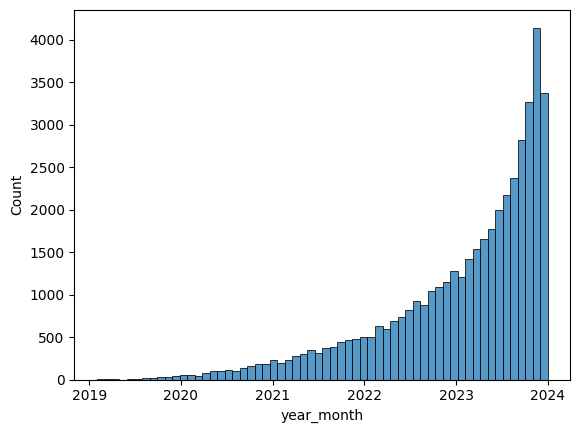

In [157]:
sns.histplot(data=repeated_user_orders, x='year_month', bins=60)

<Axes: xlabel='year_month', ylabel='Count'>

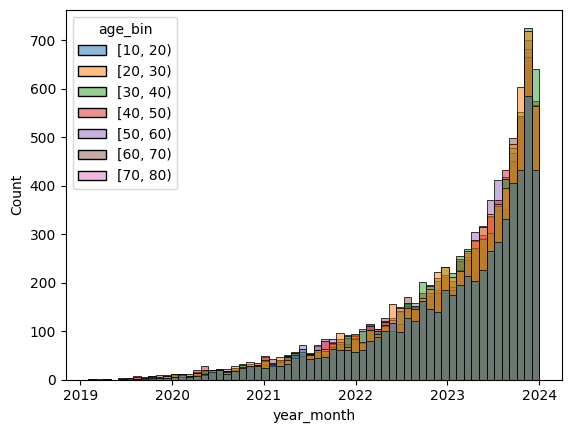

In [303]:
sns.histplot(data=repeated_user_orders, x='year_month', bins=60, hue=v[0])

<Axes: xlabel='age', ylabel='year_month'>

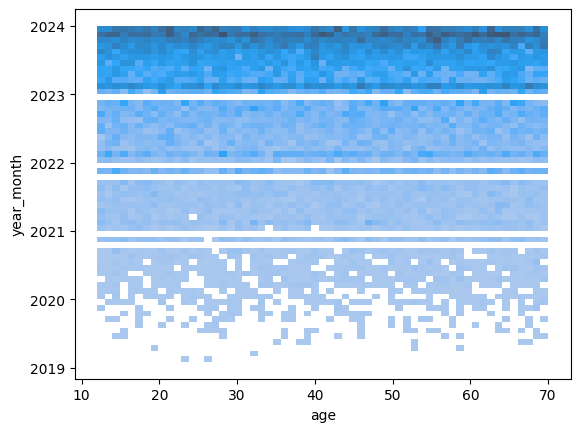

In [333]:
sns.histplot(data=repeated_user_orders, x = 'age',y='year_month', bins=59)

/tmp/ipykernel_1799/211150662.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  time_age_props = repeated_user_orders.groupby(['age_bin', 'year_month']).agg(
/tmp/ipykernel_1799/211150662.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tot_age_props = time_age_props[['age_bin', 'tot_orders', 'tot_items']].groupby('age_bin').sum().reset_index()


<Axes: xlabel='tot_item_prop', ylabel='age_bin'>

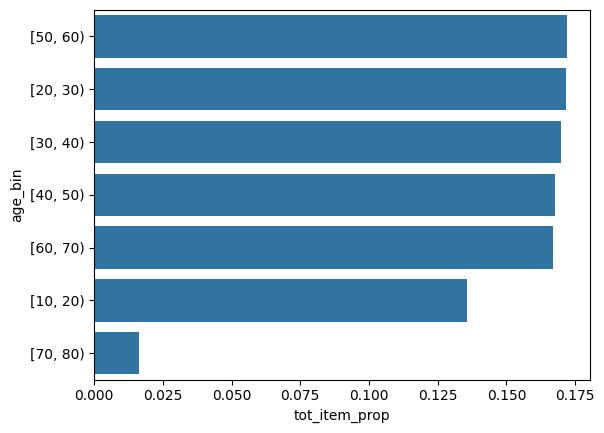

In [304]:
# total order country proportions
time_age_props = repeated_user_orders.groupby(['age_bin', 'year_month']).agg(
    tot_orders=('order_id', 'count'),
    tot_items=('n_items', 'sum'),
).reset_index()

time_age_props['total_orders_month'] = time_age_props.groupby('year_month')['tot_orders'].transform('sum')
time_age_props['total_items_month'] = time_age_props.groupby('year_month')['tot_items'].transform('sum')

time_age_props['prop_orders'] = time_age_props['tot_orders'] / time_age_props['total_orders_month']
time_age_props['prop_items']  = time_age_props['tot_items'] / time_age_props['total_items_month']


tot_age_props = time_age_props[['age_bin', 'tot_orders', 'tot_items']].groupby('age_bin').sum().reset_index()

tot_age_props['tot_order_prop'] = tot_age_props['tot_orders'] / tot_age_props['tot_orders'].sum()
tot_age_props['tot_item_prop'] = tot_age_props['tot_items'] / tot_age_props['tot_items'].sum()

sns.barplot(data=tot_age_props, x='tot_item_prop', y='age_bin', order=tot_age_props.sort_values('tot_item_prop', ascending=False)['age_bin'].values)

<Axes: xlabel='tot_order_prop', ylabel='age_bin'>

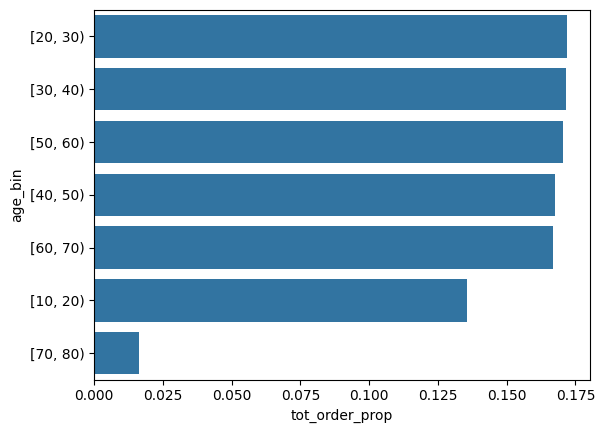

In [310]:
sns.barplot(data=tot_age_props, x='tot_order_prop', y='age_bin', order=tot_age_props.sort_values('tot_order_prop', ascending=False)['age_bin'].values)

<Axes: xlabel='year_month', ylabel='prop_orders'>

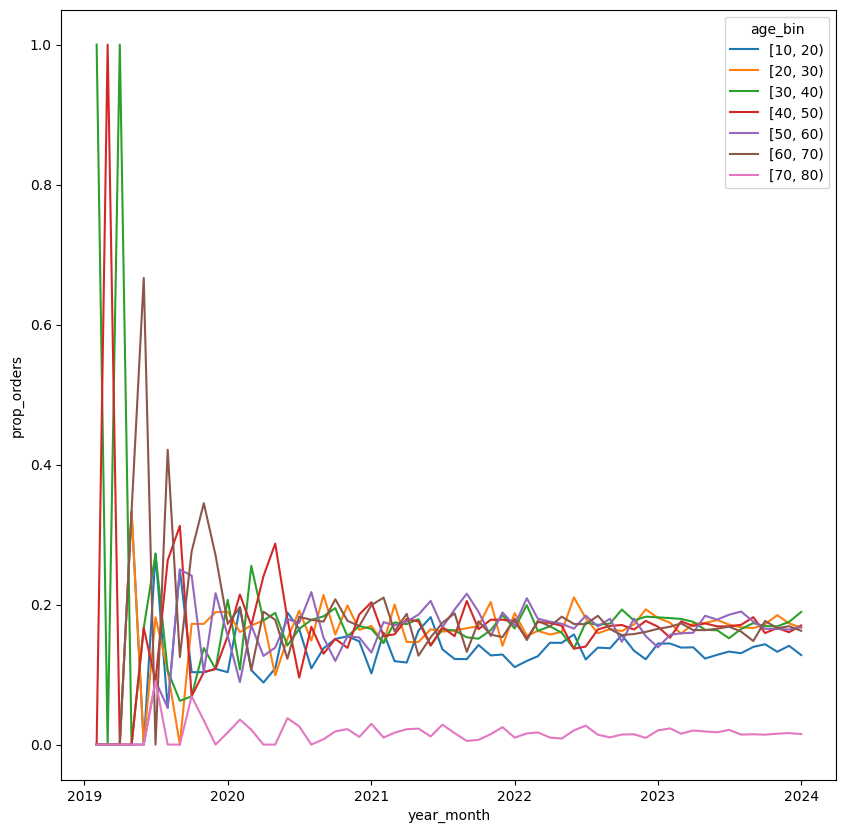

In [306]:
fig, ax = plt.subplots(figsize=(10, 10))
sns.lineplot(data=time_age_props, x='year_month', y='prop_orders', hue='traffic_source', ax=ax)

In [307]:
last_month_props = time_age_props[time_age_props['year_month'] == '2024-01-01 00:00:00']

In [308]:
tot_age_props['tot_order_prop'].values - last_month_props['prop_orders'].values

array([ 0.00778717,  0.00481032, -0.01782416, -0.00272904,  0.00256254,
        0.00422   ,  0.00117316])

<Axes: xlabel='year_month', ylabel='Count'>

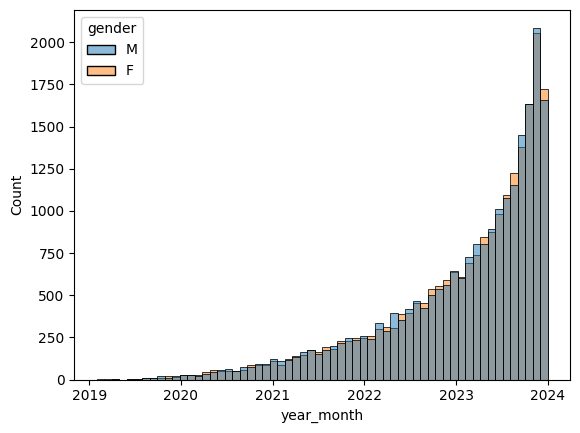

In [164]:
sns.histplot(data=repeated_user_orders, x='year_month', bins=60, hue=v[1])

<Axes: xlabel='year_month', ylabel='Count'>

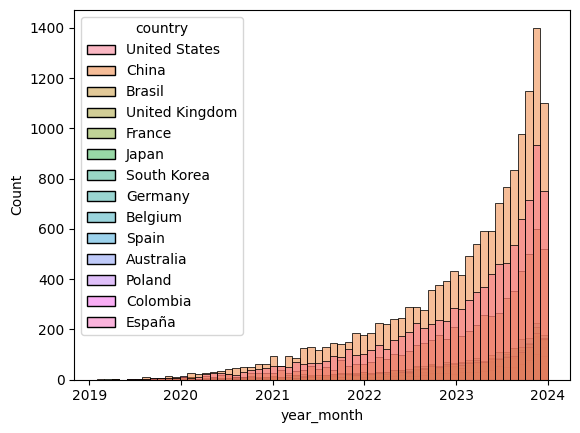

In [165]:
sns.histplot(data=repeated_user_orders, x='year_month', bins=60, hue=v[2])

<Axes: xlabel='tot_item_prop', ylabel='country'>

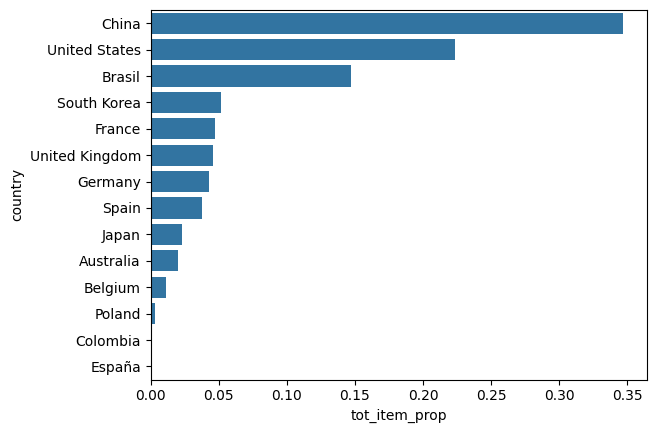

In [241]:
# total order country proportions
time_country_props = repeated_user_orders.groupby(['country', 'year_month']).agg(
    tot_orders=('order_id', 'count'),
    tot_items=('n_items', 'sum'),
).reset_index()

time_country_props['total_orders_month'] = time_country_props.groupby('year_month')['tot_orders'].transform('sum')
time_country_props['total_items_month'] = time_country_props.groupby('year_month')['tot_items'].transform('sum')

time_country_props['prop_orders'] = time_country_props['tot_orders'] / time_country_props['total_orders_month']
time_country_props['prop_items']  = time_country_props['tot_items'] / time_country_props['total_items_month']


tot_country_props = time_country_props[['country', 'tot_orders', 'tot_items']].groupby('country').sum().reset_index()

tot_country_props['tot_order_prop'] = tot_country_props['tot_orders'] / tot_country_props['tot_orders'].sum()
tot_country_props['tot_item_prop'] = tot_country_props['tot_items'] / tot_country_props['tot_items'].sum()

sns.barplot(data=tot_country_props, x='tot_item_prop', y='country', order=tot_country_props.sort_values('tot_item_prop', ascending=False)['country'].values)

<Axes: xlabel='tot_order_prop', ylabel='country'>

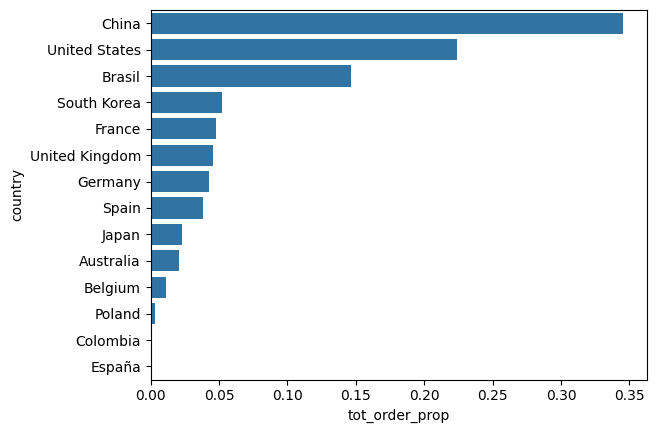

In [232]:
sns.barplot(data=tot_country_props, x='tot_order_prop', y='country', order=tot_country_props.sort_values('tot_order_prop', ascending=False)['country'].values)

<Axes: xlabel='year_month', ylabel='prop_orders'>

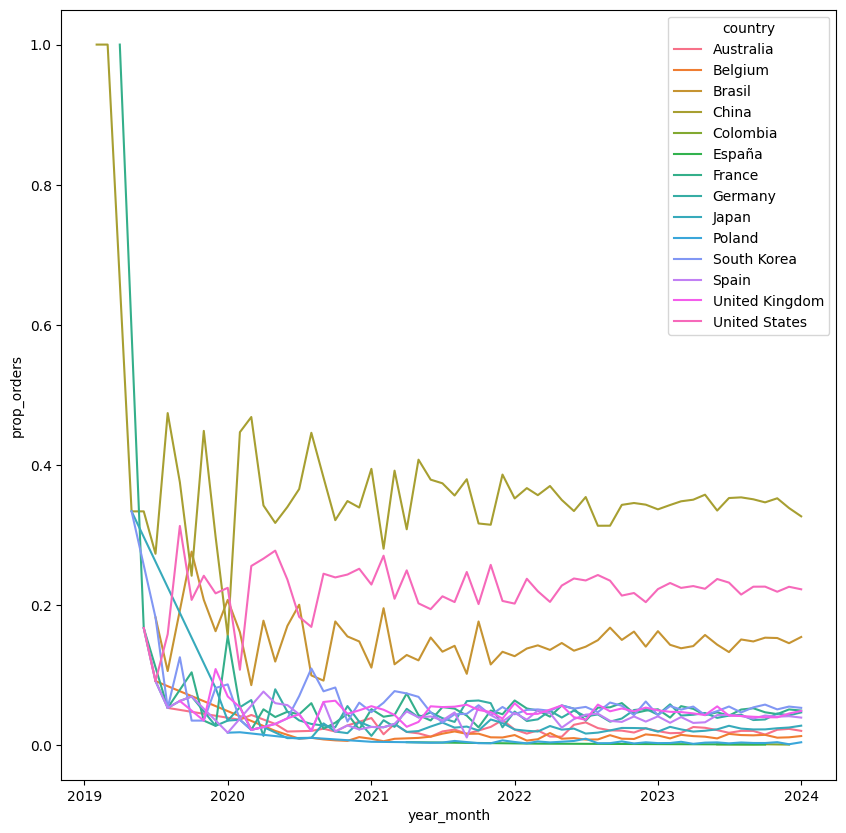

In [248]:
fig, ax = plt.subplots(figsize=(10, 10))
sns.lineplot(data=time_country_props, x='year_month', y='prop_orders', hue='country', ax=ax)

In [294]:
last_month_props = time_country_props[time_country_props['year_month'] == '2024-01-01 00:00:00']

In [295]:
tot_country_props[tot_country_props['country'].isin(['Australia', 'Belgium', 'Brasil', 'China', 'France', 'Germany',
       'Japan', 'Poland', 'South Korea', 'Spain', 'United Kingdom',
       'United States'])]['tot_order_prop'].values - last_month_props['prop_orders'].values

array([ 0.00060632, -0.00089877, -0.00754493,  0.0190851 , -0.00096204,
       -0.00378179, -0.00414314, -0.00062908, -0.00064078, -0.00025605,
       -0.00293071,  0.00189192])

<Axes: xlabel='year_month', ylabel='Count'>

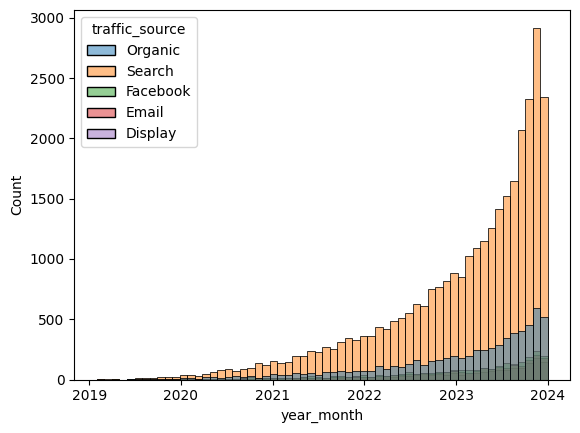

In [278]:
sns.histplot(data=repeated_user_orders, x='year_month', bins=60, hue=v[3])

<Axes: xlabel='tot_item_prop', ylabel='traffic_source'>

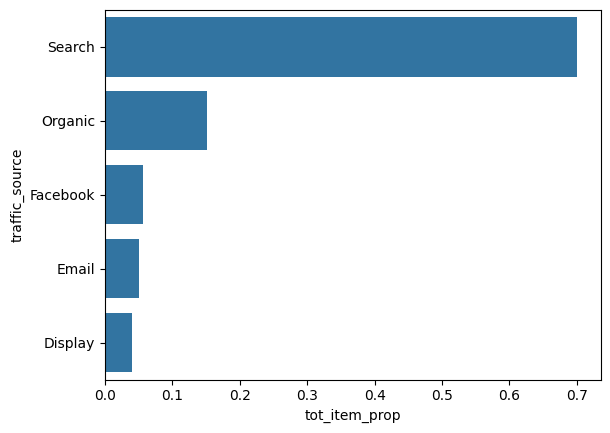

In [281]:
# total order country proportions
time_channel_props = repeated_user_orders.groupby(['traffic_source', 'year_month']).agg(
    tot_orders=('order_id', 'count'),
    tot_items=('n_items', 'sum'),
).reset_index()

time_channel_props['total_orders_month'] = time_channel_props.groupby('year_month')['tot_orders'].transform('sum')
time_channel_props['total_items_month'] = time_channel_props.groupby('year_month')['tot_items'].transform('sum')

time_channel_props['prop_orders'] = time_channel_props['tot_orders'] / time_channel_props['total_orders_month']
time_channel_props['prop_items']  = time_channel_props['tot_items'] / time_channel_props['total_items_month']


tot_channel_props = time_channel_props[['traffic_source', 'tot_orders', 'tot_items']].groupby('traffic_source').sum().reset_index()

tot_channel_props['tot_order_prop'] = tot_channel_props['tot_orders'] / tot_channel_props['tot_orders'].sum()
tot_channel_props['tot_item_prop'] = tot_channel_props['tot_items'] / tot_channel_props['tot_items'].sum()

sns.barplot(data=tot_channel_props, x='tot_item_prop', y='traffic_source', order=tot_channel_props.sort_values('tot_item_prop', ascending=False)['traffic_source'].values)

<Axes: xlabel='tot_order_prop', ylabel='traffic_source'>

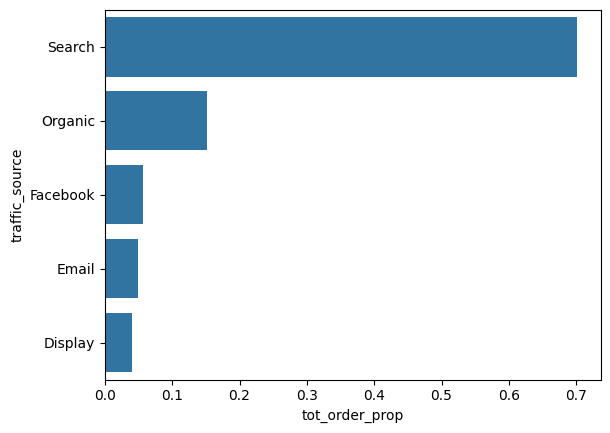

In [282]:
sns.barplot(data=tot_channel_props, x='tot_order_prop', y='age_bin', order=tot_channel_props.sort_values('tot_order_prop', ascending=False)['age_bin'].values)

<Axes: xlabel='year_month', ylabel='prop_orders'>

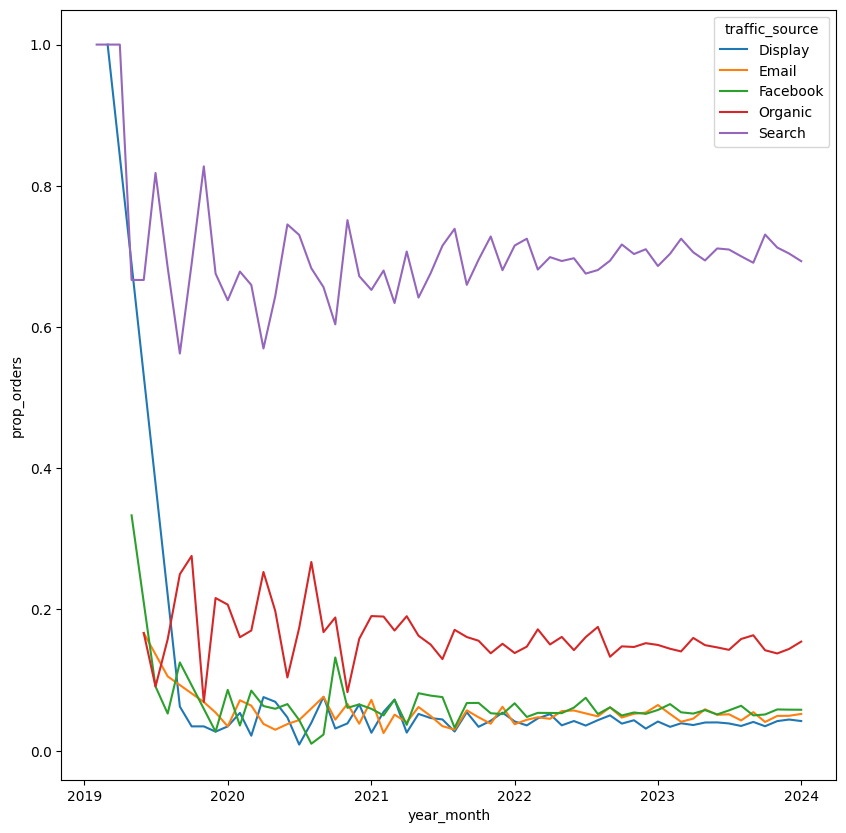

In [283]:
fig, ax = plt.subplots(figsize=(10, 10))
sns.lineplot(data=time_channel_props, x='year_month', y='prop_orders', hue='traffic_source', ax=ax)

In [296]:
last_month_props = time_channel_props[time_channel_props['year_month'] == '2024-01-01 00:00:00']

In [297]:
tot_channel_props['tot_order_prop'].values - last_month_props['prop_orders'].values

array([-0.00147289, -0.00238284, -0.00102921, -0.00349142,  0.00837635])

In [298]:
sns.histplot(data=repeated_user_orders, x='year_month', bins=60, hue=v[3])

IndexError: list index out of range

### Which customer behaviours best predict long-term value (e.g. first-purchase category, AOV, time to second order), where long-term value is defined by revenue, profit, and repeat purchases?
Metrics of interest: Long term value
- Total revenue
- Total Profit
- Repeat purchases
Dimensions of interest
- Acquisition channel
- Gender
- Country
- Age
- average order value
Other behaviours
- Average order value (bins)
- timet to second order (bins)
- first purchase category (bins)
    - Department
    - Category
    - Total order price

Actions
for each person add values according to their
- Total revenue
- Total profit
- Repeat purchases (orders)

Include
- Acquisition channel
- Gender
- Country
- Age + age bin
- Average order value + bin
- Time to second purchase + bin
- Most common category
- Most common department
- First order total revenue + bin


In [47]:
# first orders, then order items, then products

In [48]:
user_order_itms = users.merge(orders, left_on='id', right_on='user_id').merge(order_items, on='order_id').merge(products, left_on='product_id', right_on='id')
user_order_itms['month'] = user_order_itms['created_at_y'].dt.to_period('M')
user_order_itms['month'] = user_order_itms['month'].dt.to_timestamp()
user_order_itms['age_bin'] = pd.cut(
    user_order_itms['age'],
    bins=range(10, 81, 10),
    right=False
)
user_order_itms

,id_x,first_name,last_name,email,age,gender_x,state,street_address,postal_code,city,...,cost,category,name,brand,retail_price,department,sku,distribution_center_id,month,age_bin
0,457,Timothy,Bush,timothybush@example.net,65,M,Acre,87620 Johnson Hills,69917-400,Rio Branco,...,39.70,Suits & Sport Coats,Haggar Men's Shadow Stripe 2-Button Center Ven...,Haggar,99.99,Men,8671E7B4D35F3D498F22E225DBE70BD9,6,2023-10-01,"[60, 70)"
1,36280,Christopher,Mendoza,christophermendoza@example.net,13,M,Acre,125 Turner Isle Apt. 264,69917-400,Rio Branco,...,12.17,Suits & Sport Coats,Allegra K Men Worsted Long Sleeve Padded Shoul...,Allegra K,29.97,Men,8EB42DB3C9772AF6DBA6F1B9F7095FEB,9,2020-05-01,"[10, 20)"
2,36280,Christopher,Mendoza,christophermendoza@example.net,13,M,Acre,125 Turner Isle Apt. 264,69917-400,Rio Branco,...,8.79,Sleep & Lounge,Private Label - Mens Plaid Broadcloth Robe Bla...,Private Label,23.12,Men,5F7733DE9C8BDDEB31B24D3434640003,3,2021-01-01,"[10, 20)"
3,36280,Christopher,Mendoza,christophermendoza@example.net,13,M,Acre,125 Turner Isle Apt. 264,69917-400,Rio Branco,...,24.01,Shorts,Hurley Men's Sinatra Walkshort,Hurley,49.00,Men,A797A65AA8651D8B93208615C6E0D01F,1,2021-01-01,"[10, 20)"
4,60193,Jimmy,Conner,jimmyconner@example.com,64,M,Acre,0966 Jose Branch Apt. 008,69917-400,Rio Branco,...,15.31,Socks,Smartwool NEW Men's PhD Running Light Micro wi...,SmartWool,24.00,Men,A6B25CC04DE4031B55EF0AEF421EC4A4,2,2021-03-01,"[60, 70)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181754,57045,Olivia,Wiley,oliviawiley@example.org,53,F,Île-de-France,749 Ronald Forge,77320,Choisy-en-Brie,...,22.68,Active,Moving Comfort Women's Juno Bra,Moving Comfort,56.00,Women,3430095C577593AAD3C39C701712BCFE,3,2021-09-01,"[50, 60)"
181755,73312,Emily,Bird,emilybird@example.org,16,F,Île-de-France,78117 Anderson Oval,77320,Choisy-en-Brie,...,5.06,Intimates,Vanity Fair Women's Smooth Moves Brief Panty #...,Vanity Fair,9.50,Women,63E8E3643E7F7198858EEF325B0600F9,2,2023-08-01,"[10, 20)"
181756,73312,Emily,Bird,emilybird@example.org,16,F,Île-de-France,78117 Anderson Oval,77320,Choisy-en-Brie,...,35.12,Fashion Hoodies & Sweatshirts,Coolibar UPF 50+ Women's ZnO Cabana Hoodie - S...,Coolibar,69.00,Women,3A1DD98341FAFC1DFE9BCF36360E6B84,5,2023-08-01,"[10, 20)"
181757,77764,Deborah,Andrews,deborahandrews@example.com,67,F,Île-de-France,922 Jeffrey Station,77320,Choisy-en-Brie,...,87.55,Jeans,7 For All Mankind Women's Midrise Bootcut Jean,7 For All Mankind,170.99,Women,038D5463327ADDF90D282C35BE4C5EB1,8,2023-08-01,"[60, 70)"


In [49]:
user_value = user_order_itms.groupby(['id_x', 'traffic_source', 'age', 'age_bin', 'gender_x', 'country'], observed=True).agg(
    tot_rev=('sale_price', 'sum'),
    tot_cost=('cost', 'sum'),
    n_ords=('order_id', 'nunique')
).reset_index()
user_value['aov'] = user_value['tot_rev'] / user_value['n_ords']
user_value['tot_profit'] = user_value['tot_rev'] - user_value['tot_cost']
user_value['aop'] = user_value['tot_profit'] / user_value['n_ords']
user_value

,id_x,traffic_source,age,age_bin,gender_x,country,tot_rev,tot_cost,n_ords,aov,tot_profit,aop
0,1,Search,62,"[60, 70)",F,South Korea,159.99,81.13,1,159.990000,78.86,78.860
1,2,Organic,65,"[60, 70)",M,Brasil,22.00,10.38,1,22.000000,11.62,11.620
2,3,Organic,16,"[10, 20)",M,United States,402.20,196.86,4,100.550000,205.34,51.335
3,4,Search,12,"[10, 20)",F,United States,148.00,61.57,1,148.000000,86.43,86.430
4,5,Organic,52,"[50, 60)",F,Brasil,65.65,28.81,1,65.650000,36.84,36.840
...,...,...,...,...,...,...,...,...,...,...,...,...
80039,99993,Search,17,"[10, 20)",F,Australia,26.00,15.55,1,26.000000,10.45,10.450
80040,99996,Search,51,"[50, 60)",M,China,123.87,55.69,2,61.935000,68.18,34.090
80041,99998,Search,51,"[50, 60)",M,United States,116.99,59.72,3,38.996667,57.27,19.090
80042,99999,Search,13,"[10, 20)",M,Brasil,67.98,34.01,1,67.980000,33.97,33.970


In [50]:
# time to second purchase
# first sort by id_x and created_at
user_order_itms = user_order_itms.sort_values(['id_x', 'created_at_y'])

In [51]:
# group by
order_orders = user_order_itms.groupby(['id_x', 'order_id'], as_index=False).agg(
    created=('created_at_y', 'min')
)
order_orders = order_orders.sort_values(['id_x', 'created'])
order_orders['order_n'] = order_orders.groupby('id_x').cumcount()
order_orders

,id_x,order_id,created,order_n
0,1,1,2022-07-18 12:55:00,0
1,2,2,2022-02-20 10:34:00,0
4,3,5,2023-03-10 09:13:00,0
5,3,6,2023-04-02 09:13:00,1
2,3,3,2023-04-23 09:13:00,2
...,...,...,...,...
125221,99998,125222,2023-01-28 07:27:00,1
125222,99998,125223,2023-07-22 07:27:00,2
125223,99999,125224,2023-12-22 11:29:00,0
125225,100000,125226,2020-08-29 03:04:00,0


In [52]:
second_order_gap = order_orders.query('order_n in [0, 1]').pivot(index='id_x', columns='order_n', values='created')
second_order_gap

order_n,0,1
id_x,,
1,2022-07-18 12:55:00,NaT
2,2022-02-20 10:34:00,NaT
3,2023-03-10 09:13:00,2023-04-02 09:13:00
4,2022-10-18 09:31:00,NaT
5,2022-10-20 10:03:00,NaT
...,...,...
99993,2024-01-03 03:09:00,NaT
99996,2020-08-02 02:00:00,2023-03-13 02:00:00
99998,2022-12-16 07:27:00,2023-01-28 07:27:00


In [53]:
second_order_gap['time_to_second_order (days)'] = (
    second_order_gap[1] - second_order_gap[0]
).dt.days
second_order_gap = second_order_gap.reset_index()
second_order_gap
second_order_gap

order_n,id_x,0,1,time_to_second_order (days)
0,1,2022-07-18 12:55:00,NaT,NaN
1,2,2022-02-20 10:34:00,NaT,NaN
2,3,2023-03-10 09:13:00,2023-04-02 09:13:00,23.0
3,4,2022-10-18 09:31:00,NaT,NaN
4,5,2022-10-20 10:03:00,NaT,NaN
...,...,...,...,...
80039,99993,2024-01-03 03:09:00,NaT,NaN
80040,99996,2020-08-02 02:00:00,2023-03-13 02:00:00,953.0
80041,99998,2022-12-16 07:27:00,2023-01-28 07:27:00,43.0
80042,99999,2023-12-22 11:29:00,NaT,NaN


In [54]:
user_value = user_value.merge(second_order_gap.reset_index()[['id_x', 'time_to_second_order (days)']], on='id_x')
user_value

,id_x,traffic_source,age,age_bin,gender_x,country,tot_rev,tot_cost,n_ords,aov,tot_profit,aop,time_to_second_order (days)
0,1,Search,62,"[60, 70)",F,South Korea,159.99,81.13,1,159.990000,78.86,78.860,NaN
1,2,Organic,65,"[60, 70)",M,Brasil,22.00,10.38,1,22.000000,11.62,11.620,NaN
2,3,Organic,16,"[10, 20)",M,United States,402.20,196.86,4,100.550000,205.34,51.335,23.0
3,4,Search,12,"[10, 20)",F,United States,148.00,61.57,1,148.000000,86.43,86.430,NaN
4,5,Organic,52,"[50, 60)",F,Brasil,65.65,28.81,1,65.650000,36.84,36.840,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
80039,99993,Search,17,"[10, 20)",F,Australia,26.00,15.55,1,26.000000,10.45,10.450,NaN
80040,99996,Search,51,"[50, 60)",M,China,123.87,55.69,2,61.935000,68.18,34.090,953.0
80041,99998,Search,51,"[50, 60)",M,United States,116.99,59.72,3,38.996667,57.27,19.090,43.0
80042,99999,Search,13,"[10, 20)",M,Brasil,67.98,34.01,1,67.980000,33.97,33.970,NaN


In [55]:
first_order = order_orders[order_orders['order_n'] == 0]
first_order.merge(order_items, on='order_id')

,id_x,order_id,created,order_n,id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,sale_price
0,1,1,2022-07-18 12:55:00,0,1,1,2953,3,Shipped,2022-07-20 10:32:05,2022-07-20 16:42:00,NaT,NaT,15.00
1,1,1,2022-07-18 12:55:00,0,3,1,7656,9,Shipped,2022-07-19 11:29:28,2022-07-20 16:42:00,NaT,NaT,19.99
2,1,1,2022-07-18 12:55:00,0,2,1,4731,7,Shipped,2022-07-20 11:05:38,2022-07-20 16:42:00,NaT,NaT,125.00
3,2,2,2022-02-20 10:34:00,0,4,2,25774,11,Complete,2022-02-20 10:28:57,2022-02-22 12:23:00,2022-02-23 18:29:00,NaT,22.00
4,3,5,2023-03-10 09:13:00,0,7,3,18177,18,Shipped,2023-03-10 07:14:45,2023-03-11 12:33:00,NaT,NaT,109.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116107,99996,125219,2020-08-02 02:00:00,0,181749,99996,27368,490678,Processing,2020-08-01 23:33:20,NaT,NaT,NaT,40.00
116108,99998,125221,2022-12-16 07:27:00,0,181753,99998,19164,490690,Processing,2022-12-16 06:35:21,NaT,NaT,NaT,40.00
116109,99999,125224,2023-12-22 11:29:00,0,181756,99999,25959,490697,Shipped,2023-12-23 08:59:09,2023-12-24 00:44:00,NaT,NaT,25.00
116110,99999,125224,2023-12-22 11:29:00,0,181757,99999,20828,490700,Shipped,2023-12-23 11:33:17,2023-12-24 00:44:00,NaT,NaT,42.98


In [56]:
first_order = order_orders[order_orders['order_n'] == 0]
first_order_rev = first_order.merge(order_items, on='order_id').groupby('id_x').agg(
    first_order_rev = ('sale_price', 'sum')
).reset_index()
first_order_rev

,id_x,first_order_rev
0,1,159.99
1,2,22.00
2,3,109.99
3,4,148.00
4,5,65.65
...,...,...
80039,99993,26.00
80040,99996,61.00
80041,99998,40.00
80042,99999,67.98


In [57]:
user_value = user_value.merge(first_order_rev, on='id_x')

In [58]:
user_value

,id_x,traffic_source,age,age_bin,gender_x,country,tot_rev,tot_cost,n_ords,aov,tot_profit,aop,time_to_second_order (days),first_order_rev
0,1,Search,62,"[60, 70)",F,South Korea,159.99,81.13,1,159.990000,78.86,78.860,NaN,159.99
1,2,Organic,65,"[60, 70)",M,Brasil,22.00,10.38,1,22.000000,11.62,11.620,NaN,22.00
2,3,Organic,16,"[10, 20)",M,United States,402.20,196.86,4,100.550000,205.34,51.335,23.0,109.99
3,4,Search,12,"[10, 20)",F,United States,148.00,61.57,1,148.000000,86.43,86.430,NaN,148.00
4,5,Organic,52,"[50, 60)",F,Brasil,65.65,28.81,1,65.650000,36.84,36.840,NaN,65.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80039,99993,Search,17,"[10, 20)",F,Australia,26.00,15.55,1,26.000000,10.45,10.450,NaN,26.00
80040,99996,Search,51,"[50, 60)",M,China,123.87,55.69,2,61.935000,68.18,34.090,953.0,61.00
80041,99998,Search,51,"[50, 60)",M,United States,116.99,59.72,3,38.996667,57.27,19.090,43.0,40.00
80042,99999,Search,13,"[10, 20)",M,Brasil,67.98,34.01,1,67.980000,33.97,33.970,NaN,67.98


In [59]:
# now most common category
# we break ties by revenue
most_common_cat = user_order_itms.groupby(['id_x', 'category']).agg(
    n_items=('id_y', 'count'),
    cost=('cost', 'sum')
).reset_index()
most_common_cat = most_common_cat.sort_values(['id_x', 'n_items', 'cost'], ascending=False)
most_common_cat['category_pop'] = most_common_cat.groupby('id_x').cumcount()
most_common_cat = most_common_cat[most_common_cat['category_pop'] == 0][['id_x', 'category']]

user_value = user_value.merge(most_common_cat, on='id_x', how='left')
user_value

,id_x,traffic_source,age,age_bin,gender_x,country,tot_rev,tot_cost,n_ords,aov,tot_profit,aop,time_to_second_order (days),first_order_rev,category
0,1,Search,62,"[60, 70)",F,South Korea,159.99,81.13,1,159.990000,78.86,78.860,NaN,159.99,Jeans
1,2,Organic,65,"[60, 70)",M,Brasil,22.00,10.38,1,22.000000,11.62,11.620,NaN,22.00,Underwear
2,3,Organic,16,"[10, 20)",M,United States,402.20,196.86,4,100.550000,205.34,51.335,23.0,109.99,Active
3,4,Search,12,"[10, 20)",F,United States,148.00,61.57,1,148.000000,86.43,86.430,NaN,148.00,Sweaters
4,5,Organic,52,"[50, 60)",F,Brasil,65.65,28.81,1,65.650000,36.84,36.840,NaN,65.65,Sweaters
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80039,99993,Search,17,"[10, 20)",F,Australia,26.00,15.55,1,26.000000,10.45,10.450,NaN,26.00,Sleep & Lounge
80040,99996,Search,51,"[50, 60)",M,China,123.87,55.69,2,61.935000,68.18,34.090,953.0,61.00,Socks
80041,99998,Search,51,"[50, 60)",M,United States,116.99,59.72,3,38.996667,57.27,19.090,43.0,40.00,Tops & Tees
80042,99999,Search,13,"[10, 20)",M,Brasil,67.98,34.01,1,67.980000,33.97,33.970,NaN,67.98,Jeans


In [60]:
# now most common department
# we break ties by revenue
most_common_dep = user_order_itms.groupby(['id_x', 'department']).agg(
    n_items=('id_y', 'count'),
    cost=('cost', 'sum')
).reset_index()


most_common_dep = most_common_dep.sort_values(['id_x', 'n_items', 'cost'], ascending=False)
most_common_dep['dep_pop'] = most_common_dep.groupby('id_x').cumcount()
most_common_dep = most_common_dep[most_common_dep['dep_pop'] == 0][['id_x', 'department']]

user_value = user_value.merge(most_common_dep, on='id_x')
user_value

,id_x,traffic_source,age,age_bin,gender_x,country,tot_rev,tot_cost,n_ords,aov,tot_profit,aop,time_to_second_order (days),first_order_rev,category,department
0,1,Search,62,"[60, 70)",F,South Korea,159.99,81.13,1,159.990000,78.86,78.860,NaN,159.99,Jeans,Women
1,2,Organic,65,"[60, 70)",M,Brasil,22.00,10.38,1,22.000000,11.62,11.620,NaN,22.00,Underwear,Men
2,3,Organic,16,"[10, 20)",M,United States,402.20,196.86,4,100.550000,205.34,51.335,23.0,109.99,Active,Men
3,4,Search,12,"[10, 20)",F,United States,148.00,61.57,1,148.000000,86.43,86.430,NaN,148.00,Sweaters,Women
4,5,Organic,52,"[50, 60)",F,Brasil,65.65,28.81,1,65.650000,36.84,36.840,NaN,65.65,Sweaters,Women
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80039,99993,Search,17,"[10, 20)",F,Australia,26.00,15.55,1,26.000000,10.45,10.450,NaN,26.00,Sleep & Lounge,Women
80040,99996,Search,51,"[50, 60)",M,China,123.87,55.69,2,61.935000,68.18,34.090,953.0,61.00,Socks,Men
80041,99998,Search,51,"[50, 60)",M,United States,116.99,59.72,3,38.996667,57.27,19.090,43.0,40.00,Tops & Tees,Men
80042,99999,Search,13,"[10, 20)",M,Brasil,67.98,34.01,1,67.980000,33.97,33.970,NaN,67.98,Jeans,Men


In [ ]:
user_order_itms['age_bin'] = pd.cut(
    user_order_itms['age'],
    bins=range(10, 81, 10),
    right=False
)

In [111]:
(user_value['first_order_rev'].min(),
 user_value['first_order_rev'].max())

(np.float64(0.49), np.float64(1341.49))

In [112]:
# finally bin behaviours into categories
user_value['ttso_bin'] = pd.cut(
    user_value['time_to_second_order (days)'],
    bins=range(0, 1750, 250),
    right=False
)
user_value['first_order_rev_bin'] = pd.cut(
    user_value['first_order_rev'],
    bins=range(0, 1500, 250),
    right=False
)

## Visualisations

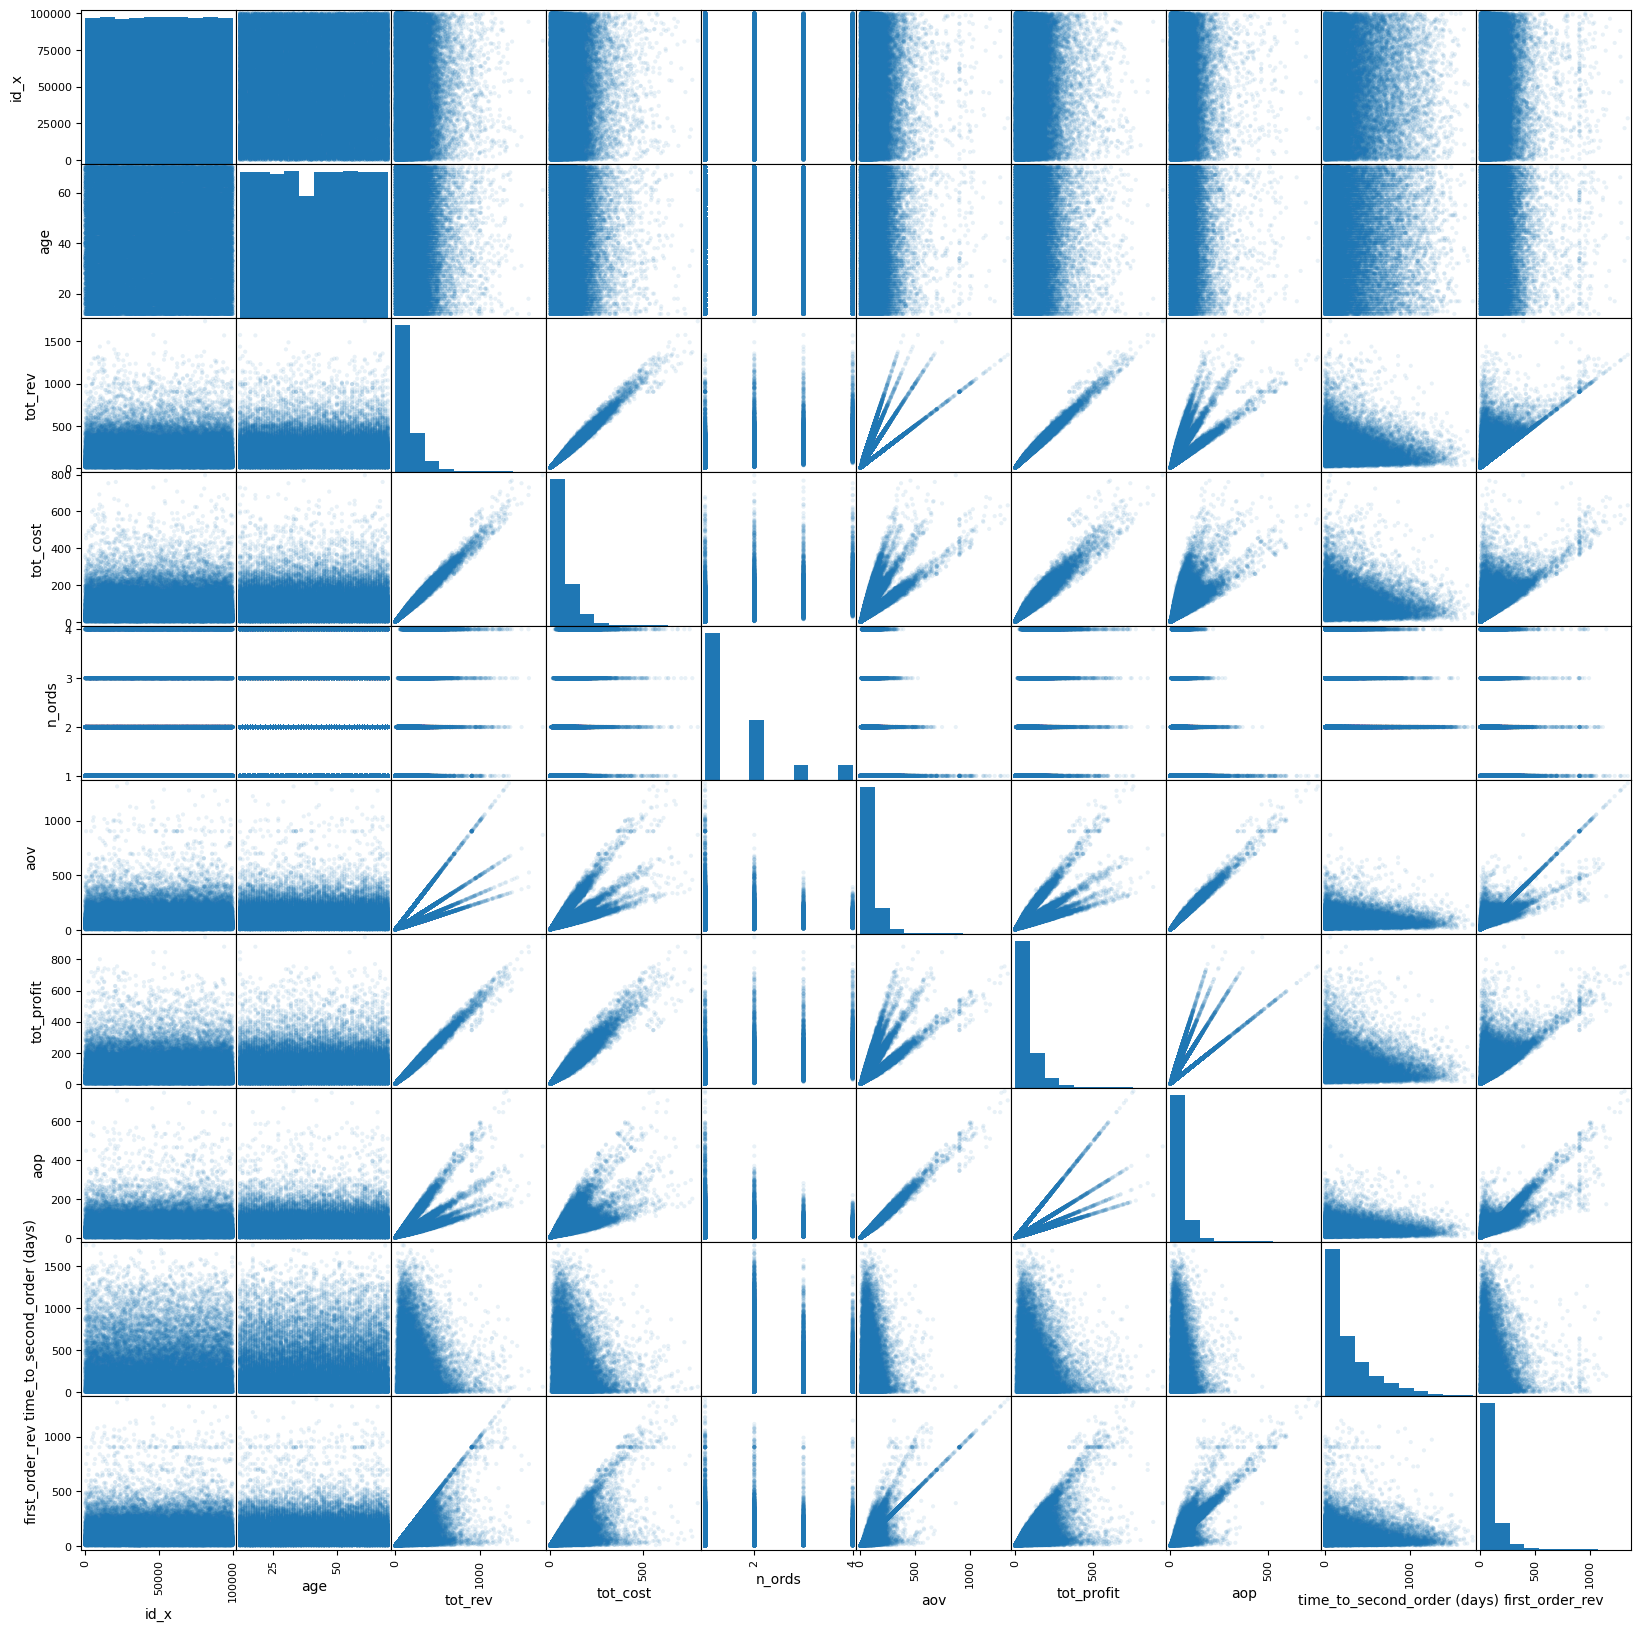

In [62]:
pd.plotting.scatter_matrix(user_value, alpha=0.1, diagonal='hist', figsize=(20, 20))
plt.show()

In [63]:
user_value

,id_x,traffic_source,age,age_bin,gender_x,country,tot_rev,tot_cost,n_ords,aov,tot_profit,aop,time_to_second_order (days),first_order_rev,category,department
0,1,Search,62,"[60, 70)",F,South Korea,159.99,81.13,1,159.990000,78.86,78.860,NaN,159.99,Jeans,Women
1,2,Organic,65,"[60, 70)",M,Brasil,22.00,10.38,1,22.000000,11.62,11.620,NaN,22.00,Underwear,Men
2,3,Organic,16,"[10, 20)",M,United States,402.20,196.86,4,100.550000,205.34,51.335,23.0,109.99,Active,Men
3,4,Search,12,"[10, 20)",F,United States,148.00,61.57,1,148.000000,86.43,86.430,NaN,148.00,Sweaters,Women
4,5,Organic,52,"[50, 60)",F,Brasil,65.65,28.81,1,65.650000,36.84,36.840,NaN,65.65,Sweaters,Women
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80039,99993,Search,17,"[10, 20)",F,Australia,26.00,15.55,1,26.000000,10.45,10.450,NaN,26.00,Sleep & Lounge,Women
80040,99996,Search,51,"[50, 60)",M,China,123.87,55.69,2,61.935000,68.18,34.090,953.0,61.00,Socks,Men
80041,99998,Search,51,"[50, 60)",M,United States,116.99,59.72,3,38.996667,57.27,19.090,43.0,40.00,Tops & Tees,Men
80042,99999,Search,13,"[10, 20)",M,Brasil,67.98,34.01,1,67.980000,33.97,33.970,NaN,67.98,Jeans,Men


Metrics of interest: Long term value
- Total revenue
- Total Profit
- aov
- aop
User characteristics
- Age
- Gender
- Country
User behaviours
- Acquisition channel
- time to second order
- first order revenue
- most common category
- most common department

In [113]:
ltv = ['tot_rev', 'tot_profit', 'aov', 'aop']
c = ['age', 'gender_x', 'country']
b = ['n_ords', 'time_to_second_order (days)', 'ttso_bin', 'first_order_rev', 'first_order_rev_bin', 'traffic_source', 'category', 'department']

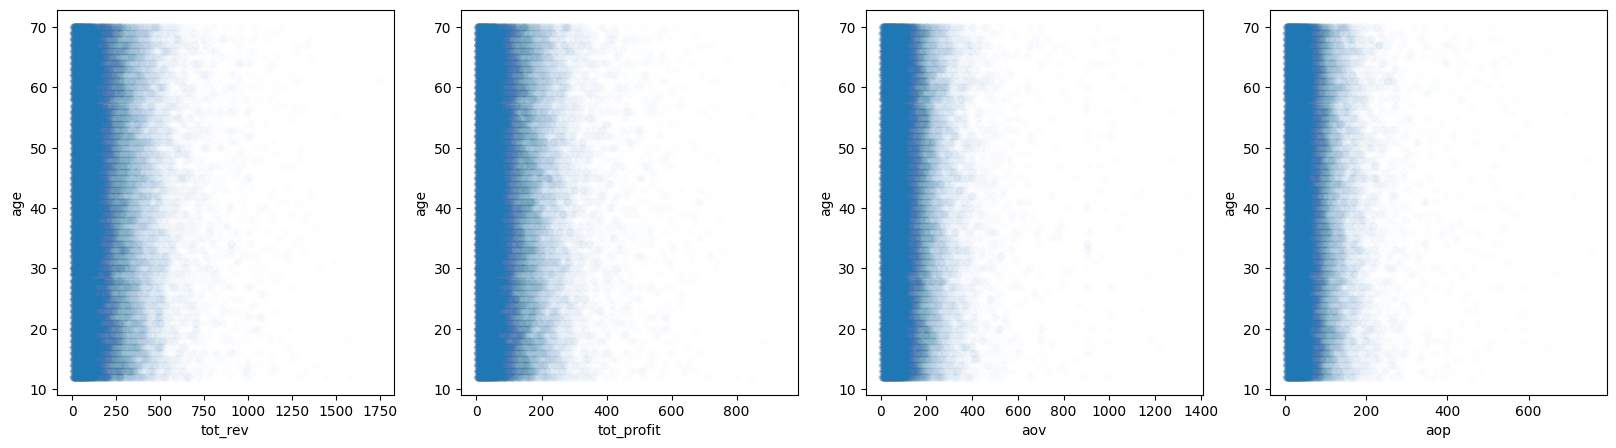

In [90]:
fig, ax = plt.subplots(1, len(ltv), figsize = (20, 5))
v = c[0]
for i in range(len(ltv)):
    sns.scatterplot(data=user_value, x=ltv[i], y = v, ax=ax[i], alpha=0.01)
plt.show()

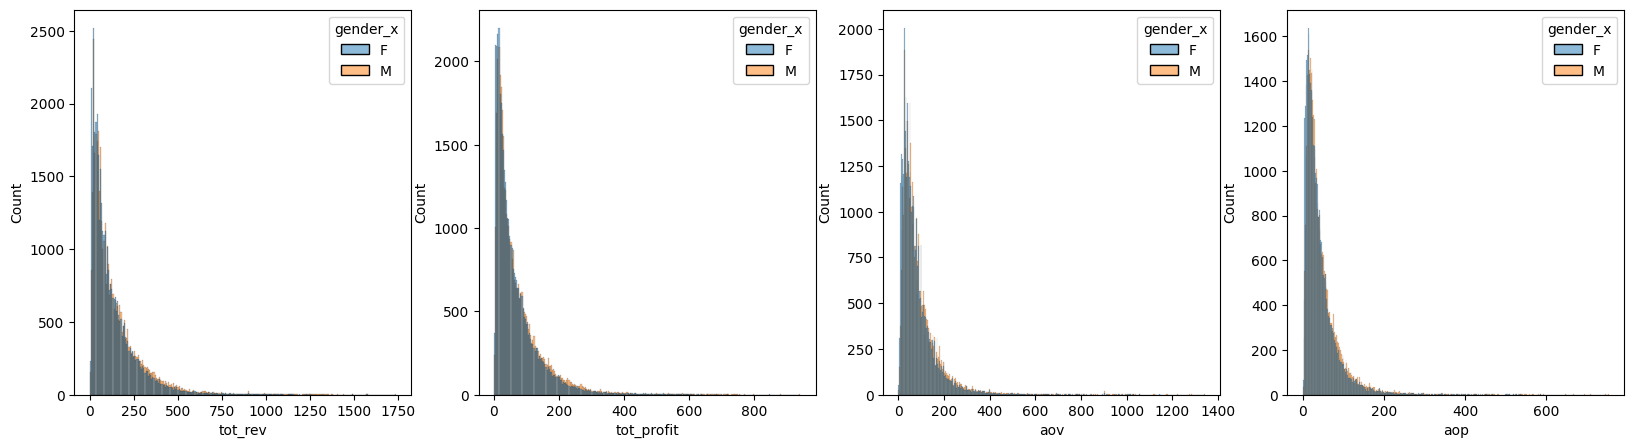

In [91]:
fig, ax = plt.subplots(1, len(ltv), figsize = (20, 5))
v = c[1]
for i in range(len(ltv)):
    sns.histplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

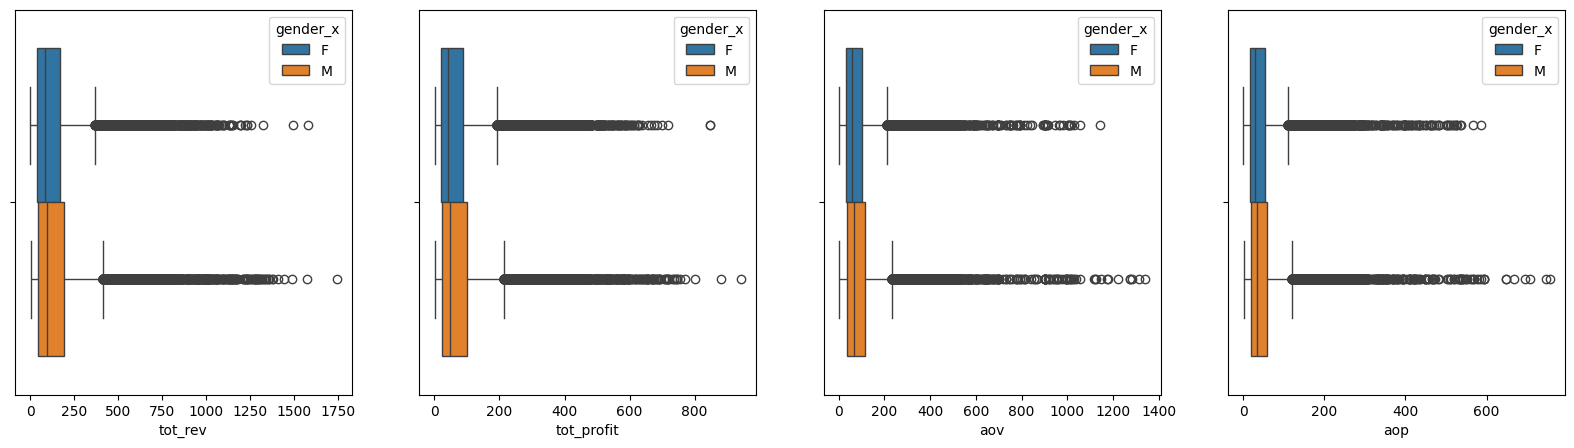

In [125]:
fig, ax = plt.subplots(1, len(ltv), figsize = (20, 5))
v = c[1]
for i in range(len(ltv)):
    sns.boxplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

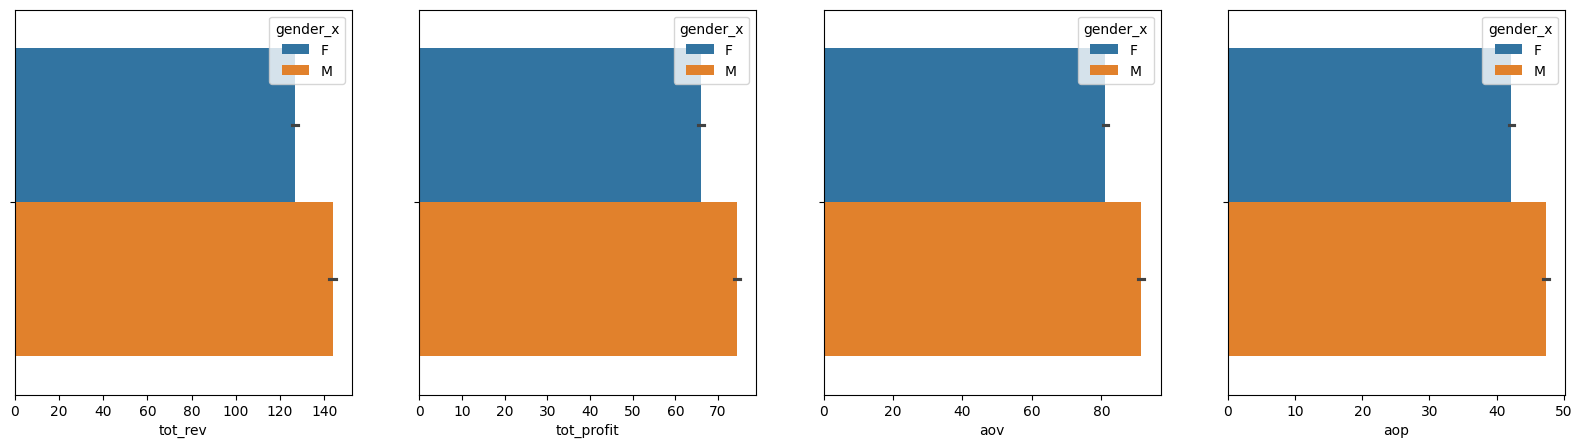

In [126]:
fig, ax = plt.subplots(1, len(ltv), figsize = (20, 5))
v = c[1]
for i in range(len(ltv)):
    sns.barplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

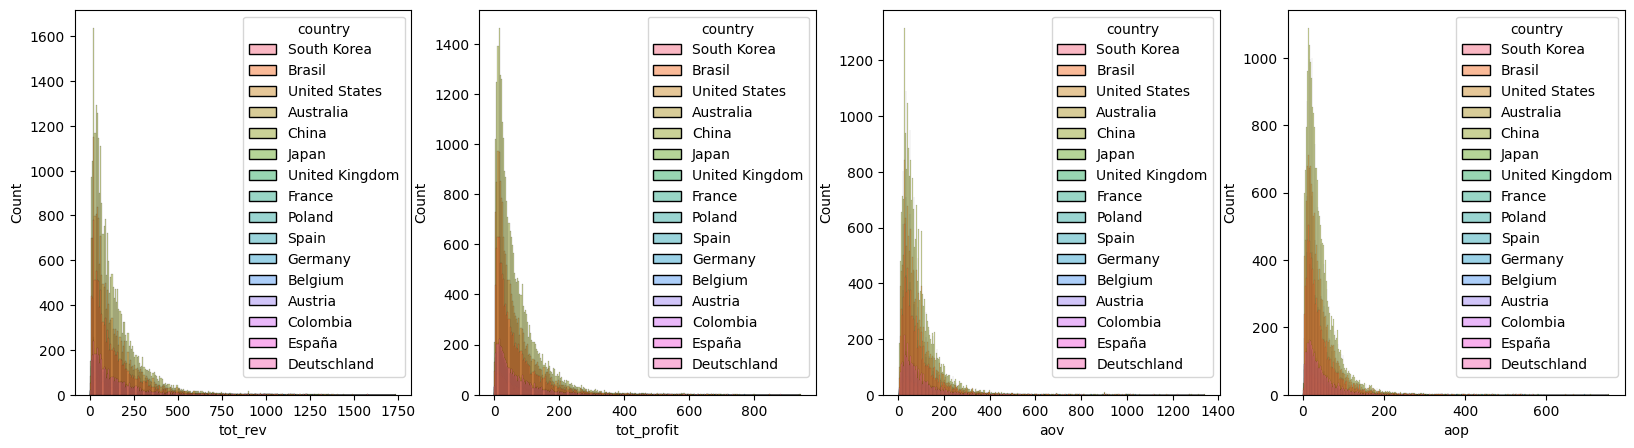

In [92]:
fig, ax = plt.subplots(1, len(ltv), figsize = (20, 5))
v = c[2]
for i in range(len(ltv)):
    sns.histplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

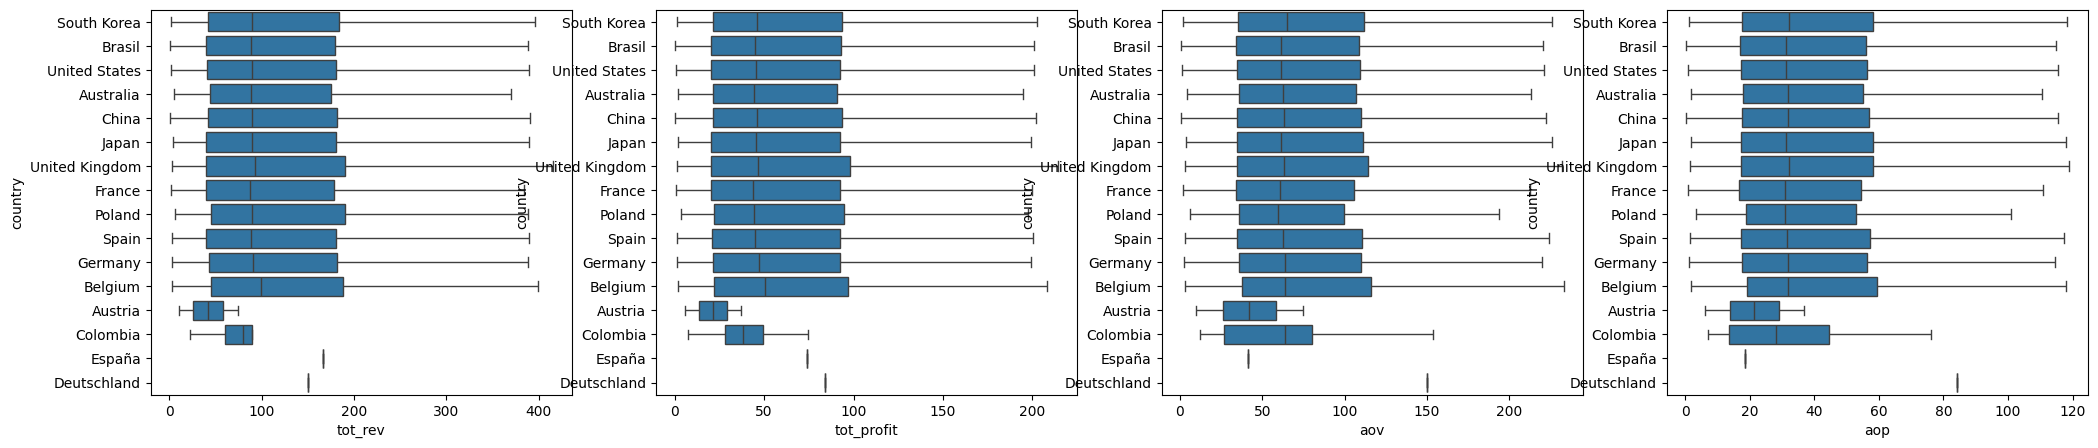

In [93]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = c[2]
for i in range(len(ltv)):
    sns.boxplot(data=user_value, x=ltv[i], y = v, ax=ax[i], showfliers=False)
plt.show()

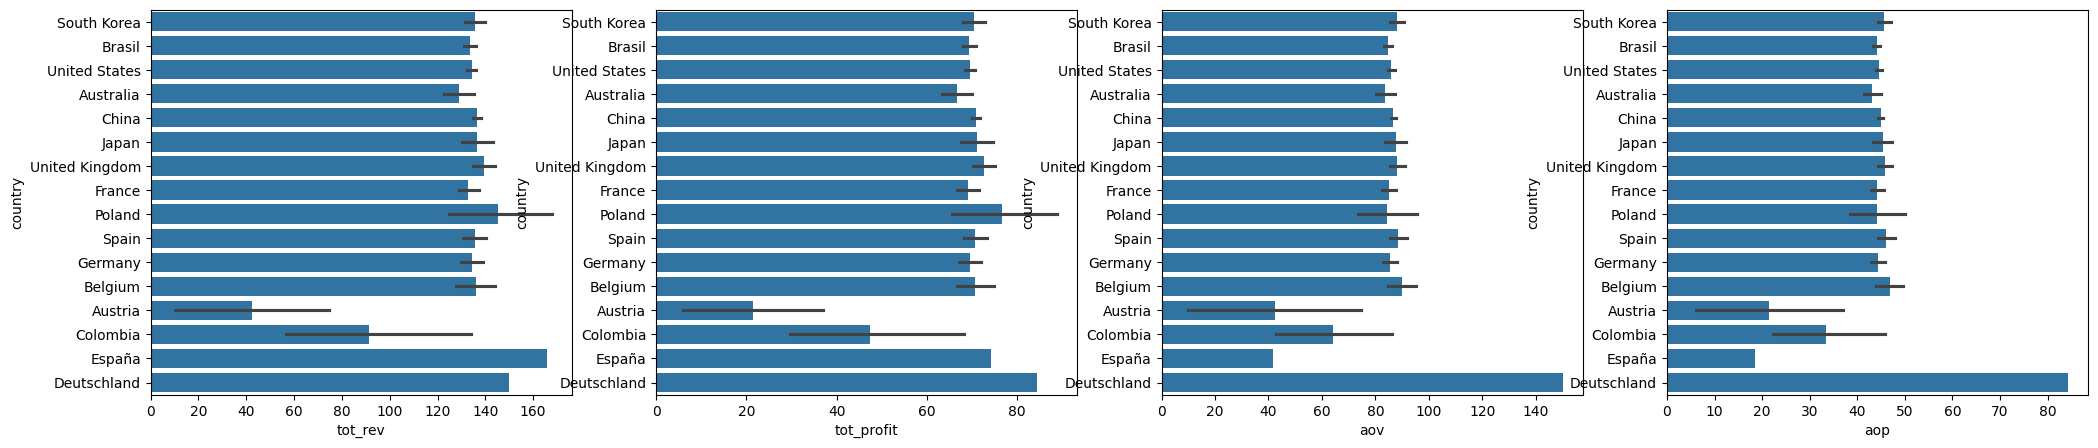

In [94]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = c[2]
for i in range(len(ltv)):
    sns.barplot(data=user_value, x=ltv[i], y = v, ax=ax[i])
plt.show()

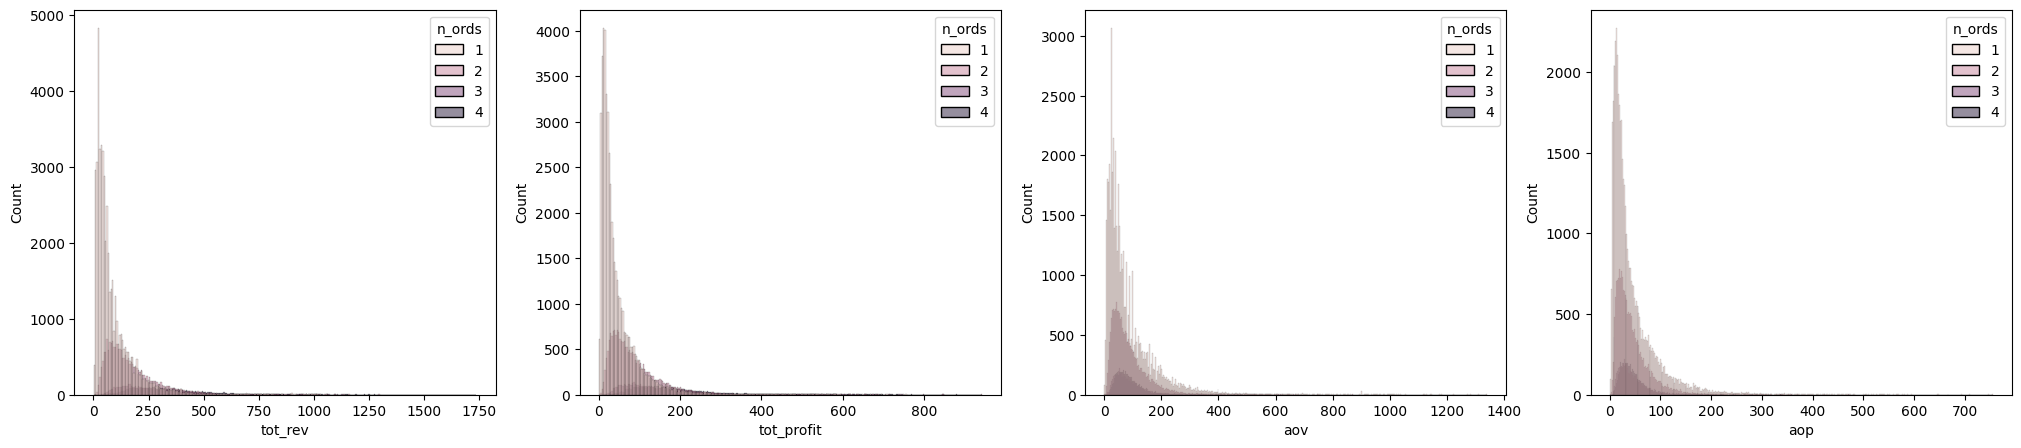

In [95]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[0]
for i in range(len(ltv)):
    sns.histplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

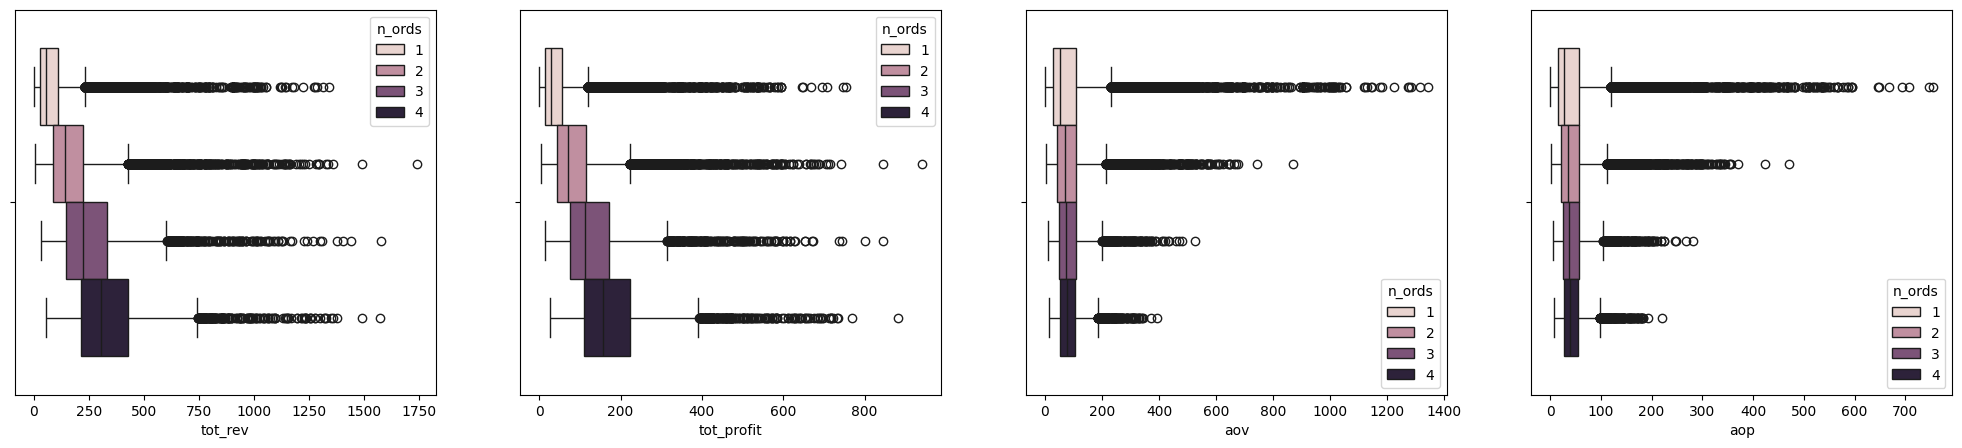

In [96]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[0]
for i in range(len(ltv)):
    sns.boxplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

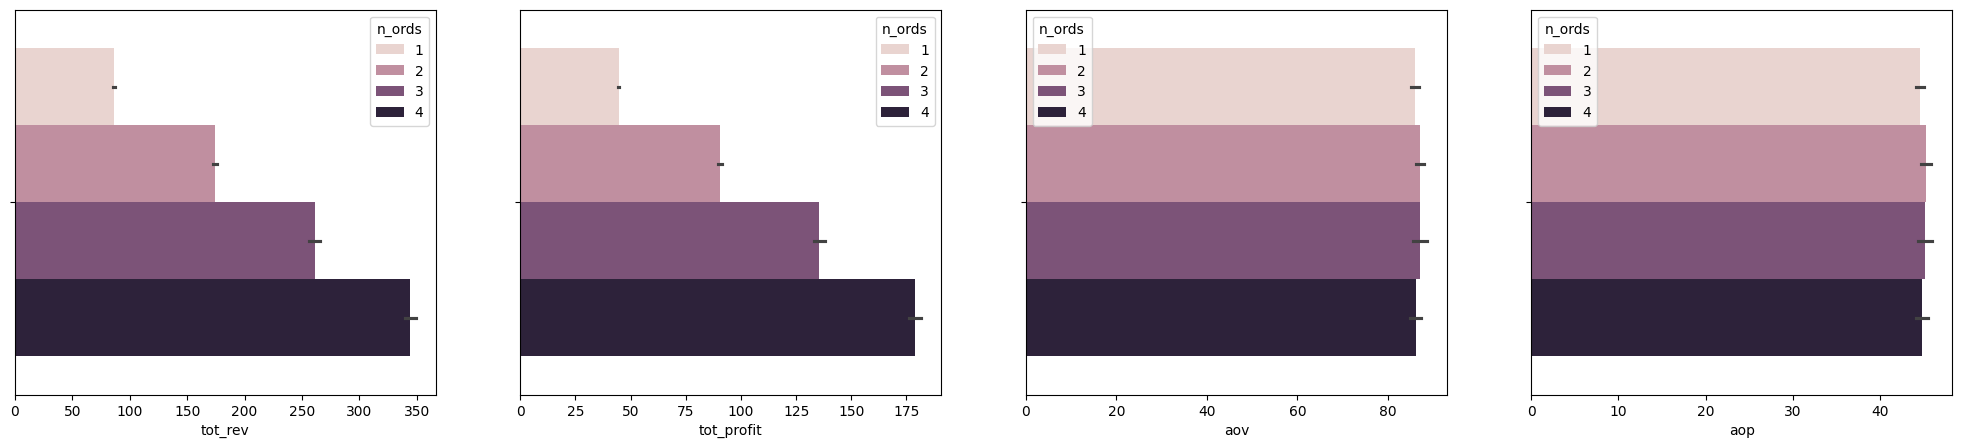

In [97]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[0]
for i in range(len(ltv)):
    sns.barplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

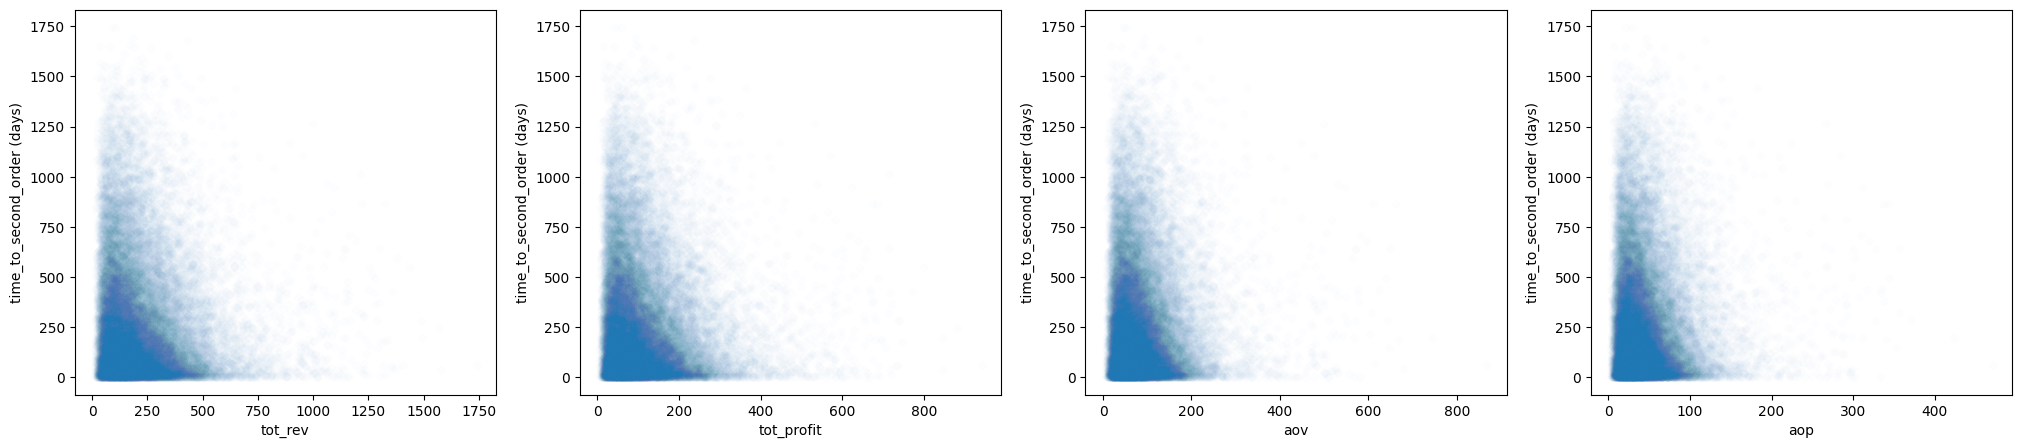

In [98]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[1]
for i in range(len(ltv)):
    sns.scatterplot(data=user_value, x=ltv[i], y = v, ax=ax[i], alpha=0.01)
plt.show()

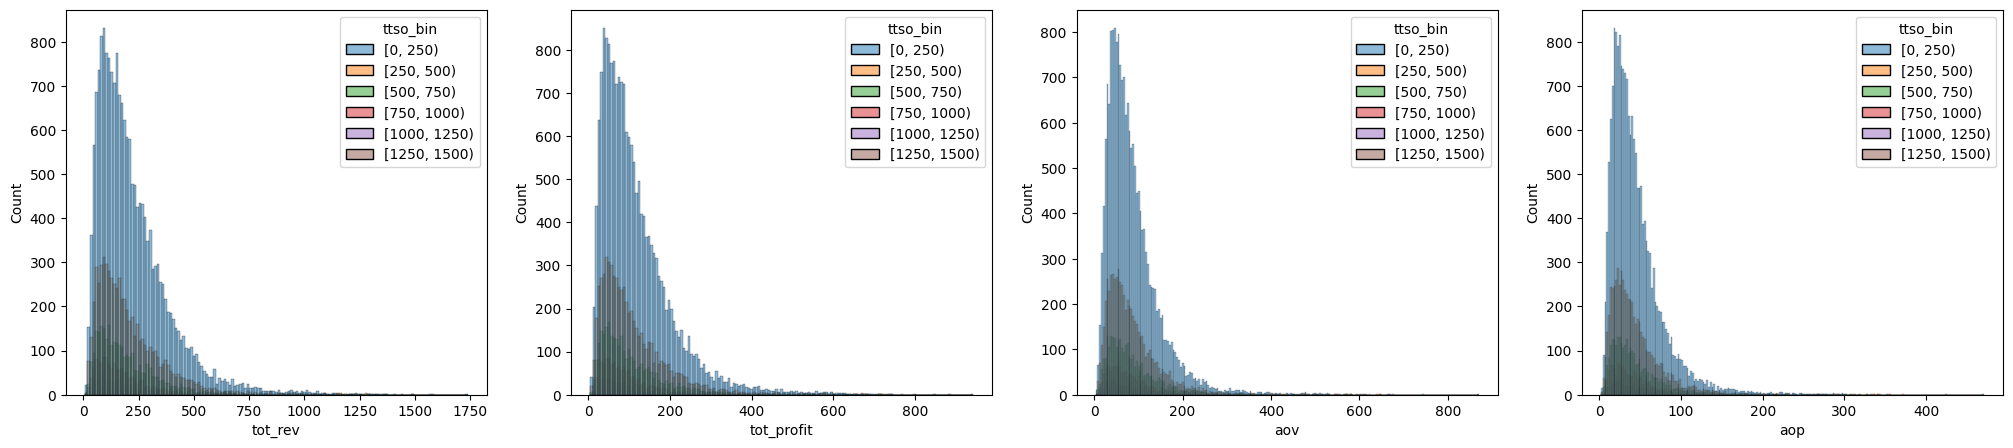

In [99]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[2]
for i in range(len(ltv)):
    sns.histplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

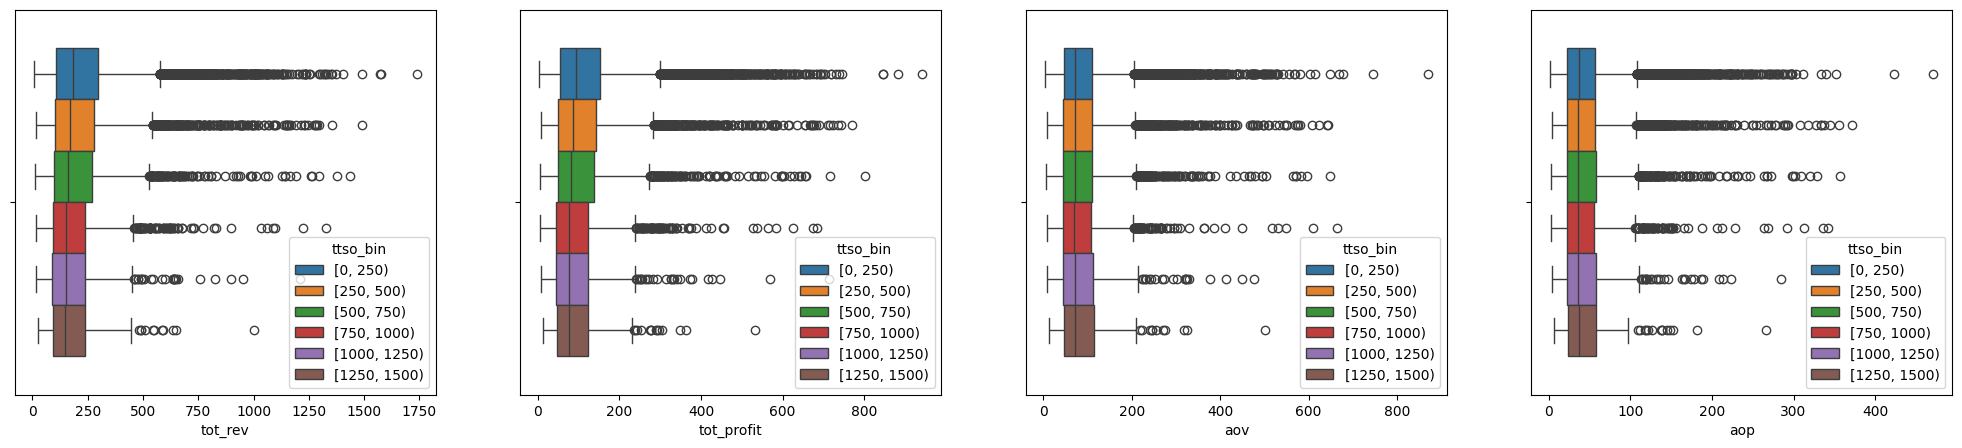

In [100]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[2]
for i in range(len(ltv)):
    sns.boxplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

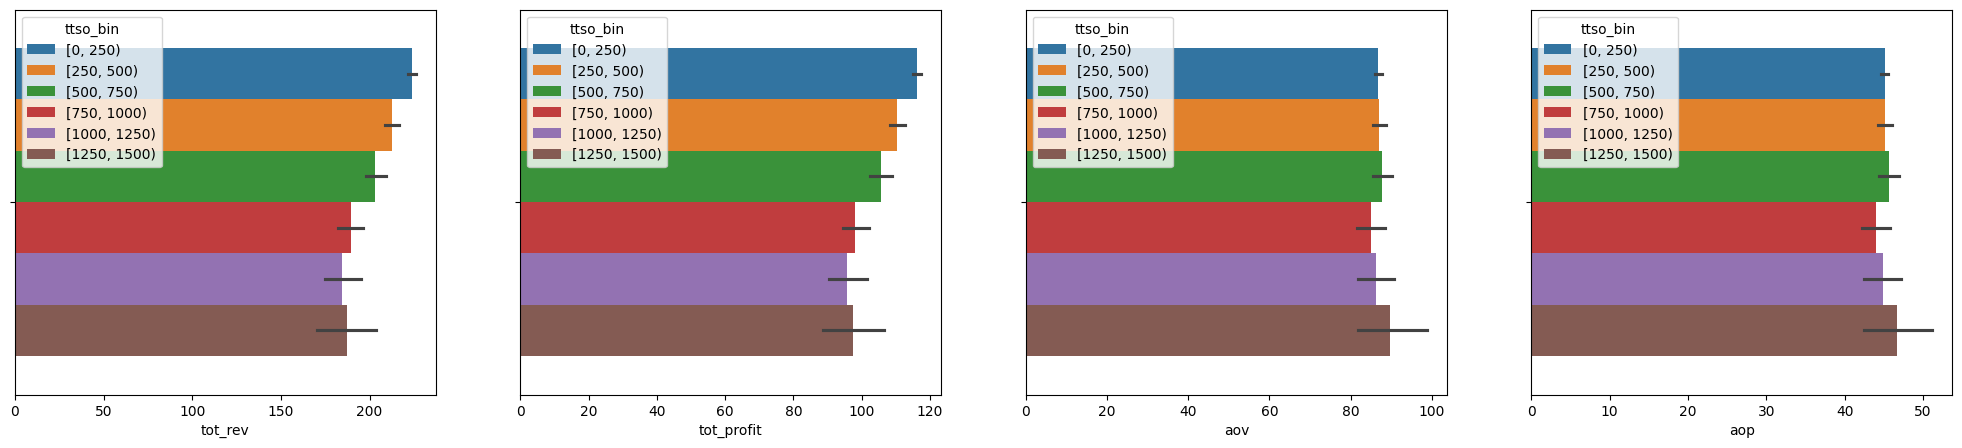

In [101]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[2]
for i in range(len(ltv)):
    sns.barplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

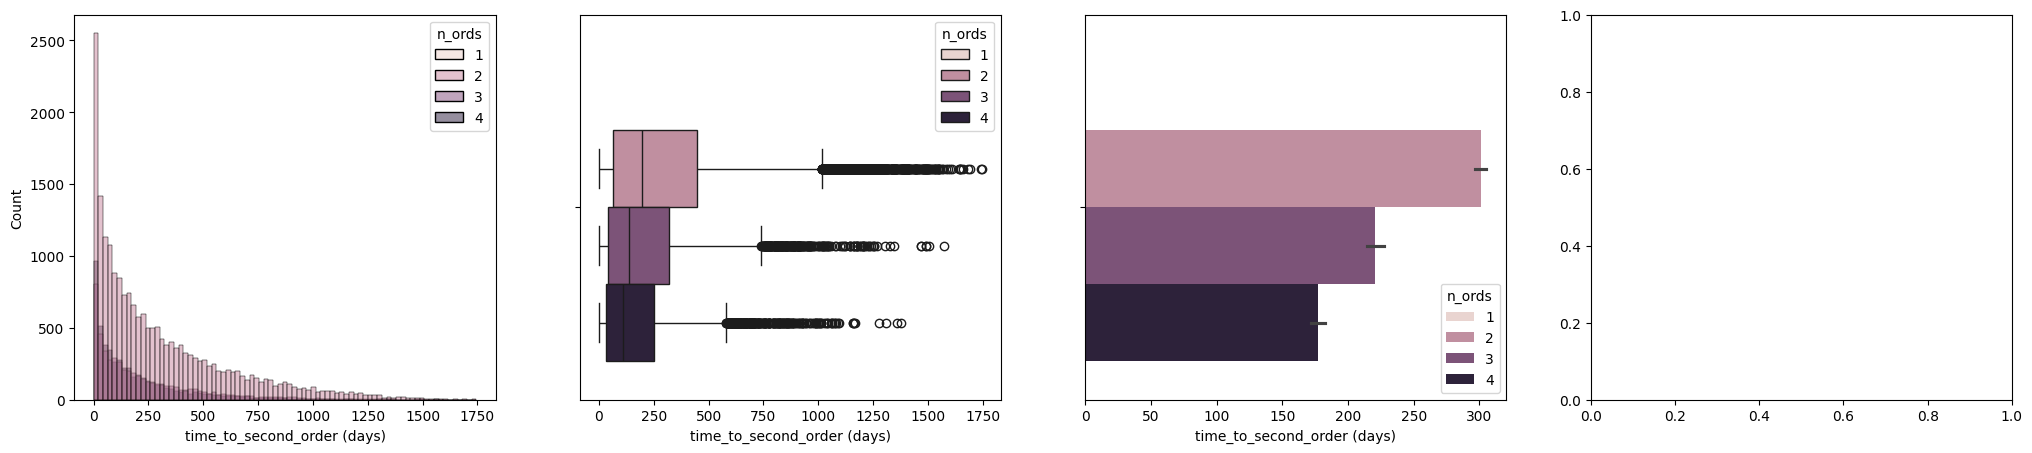

In [106]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[2]
sns.histplot(data=user_value, x='time_to_second_order (days)', hue = 'n_ords', ax=ax[0])
sns.boxplot(data=user_value, x='time_to_second_order (days)', hue = 'n_ords', ax=ax[1])
sns.barplot(data=user_value, x='time_to_second_order (days)', hue = 'n_ords', ax=ax[2])
plt.show()

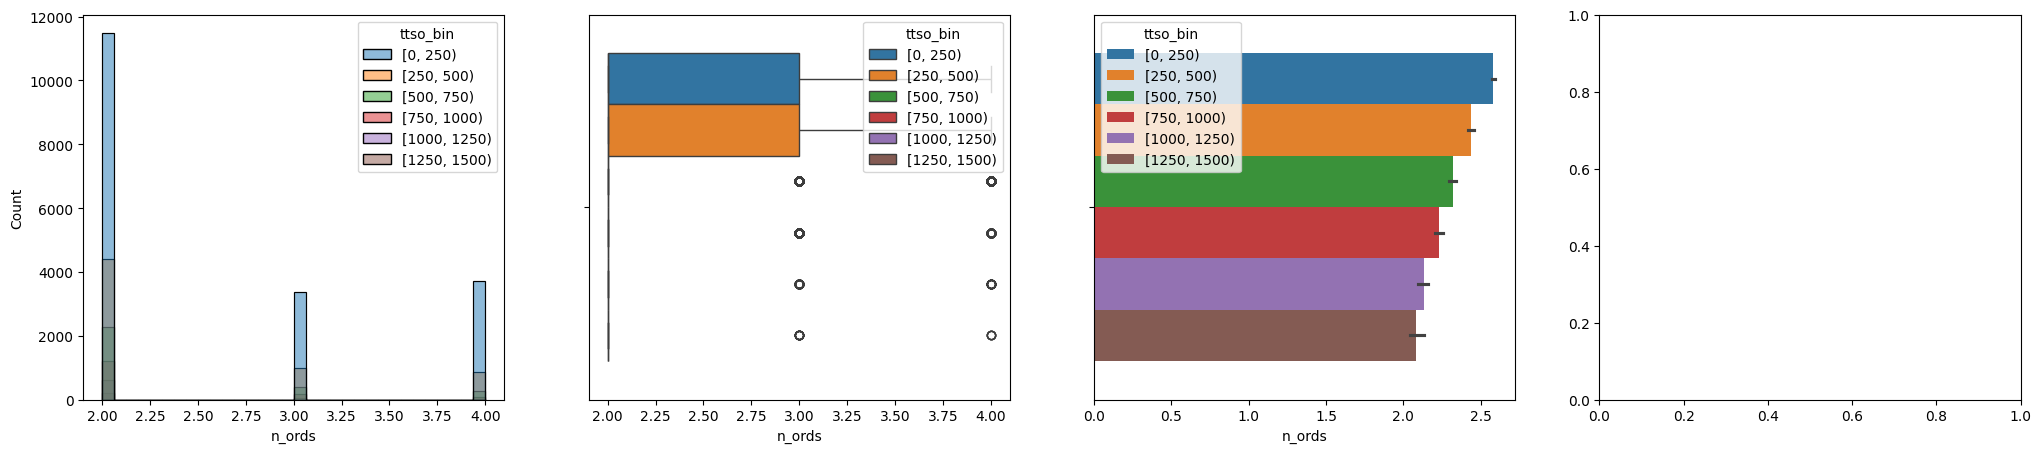

In [107]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[2]
sns.histplot(data=user_value, x='n_ords', hue = 'ttso_bin', ax=ax[0])
sns.boxplot(data=user_value, x='n_ords', hue = 'ttso_bin', ax=ax[1])
sns.barplot(data=user_value, x='n_ords', hue = 'ttso_bin', ax=ax[2])
plt.show()

In [108]:
b[3]

'first_order_rev'

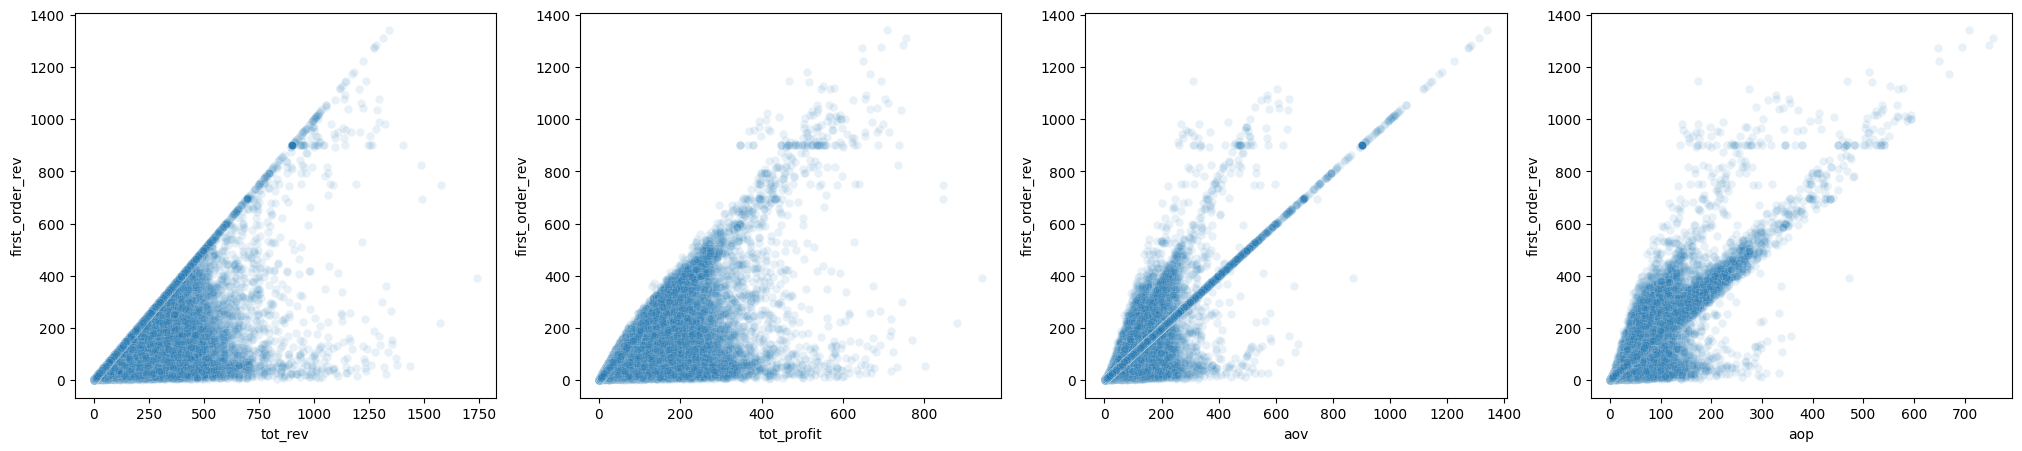

In [110]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[3]
for i in range(len(ltv)):
    sns.scatterplot(data=user_value, x=ltv[i], y = v, ax=ax[i], alpha=0.1)
plt.show()

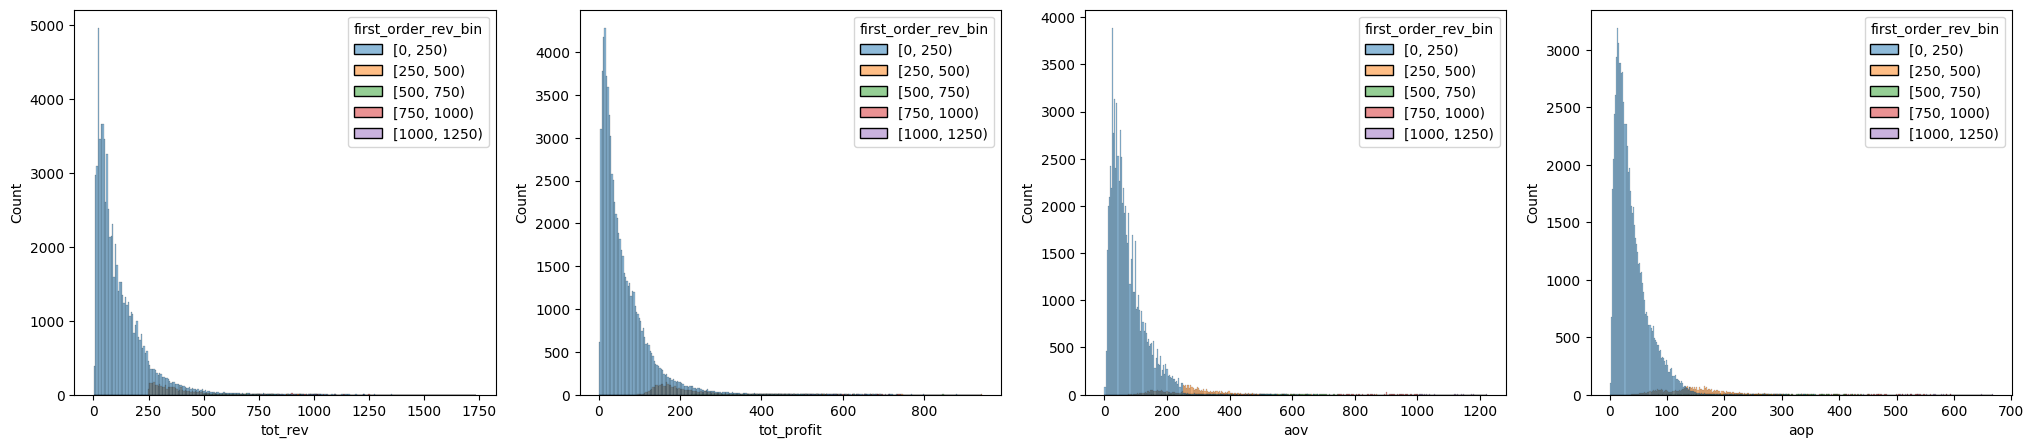

In [114]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[4]
for i in range(len(ltv)):
    sns.histplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

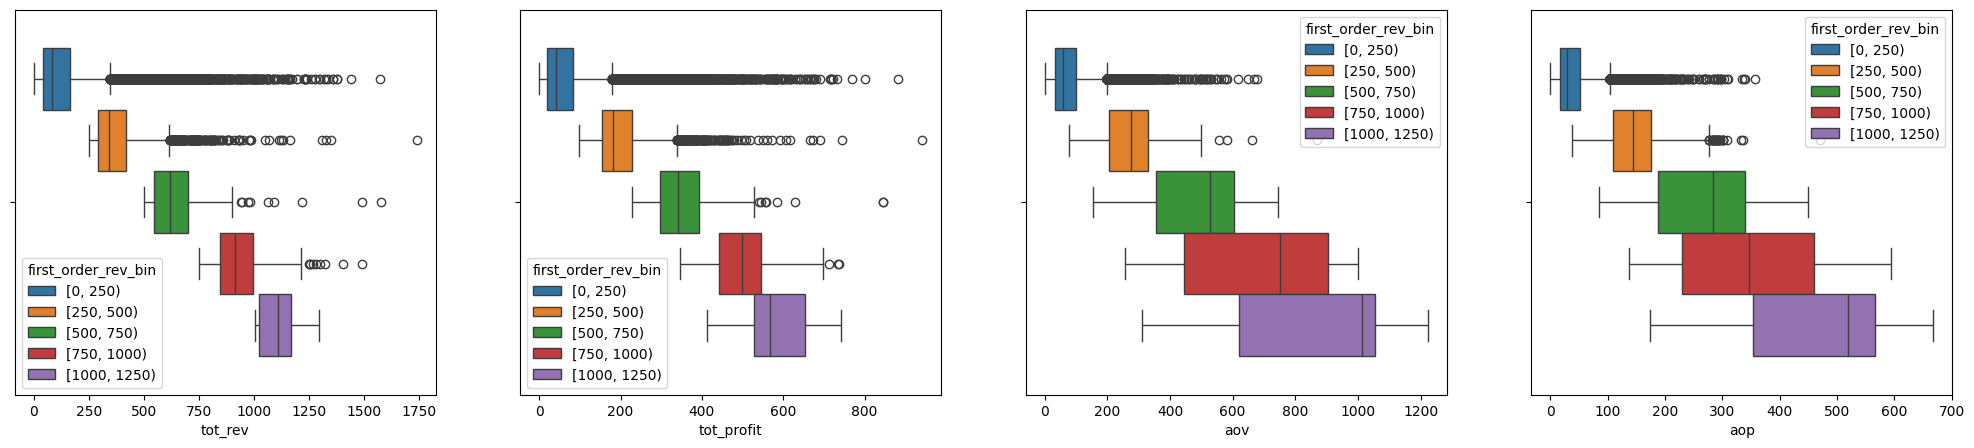

In [115]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[4]
for i in range(len(ltv)):
    sns.boxplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

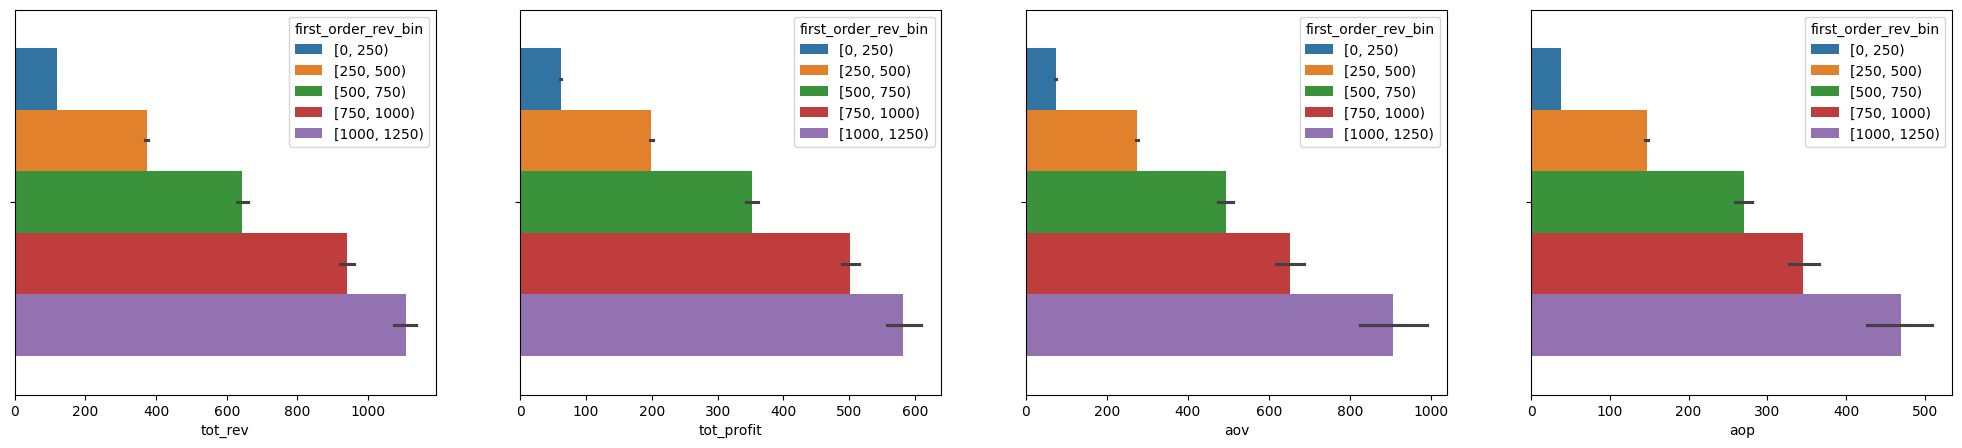

In [116]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[4]
for i in range(len(ltv)):
    sns.barplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

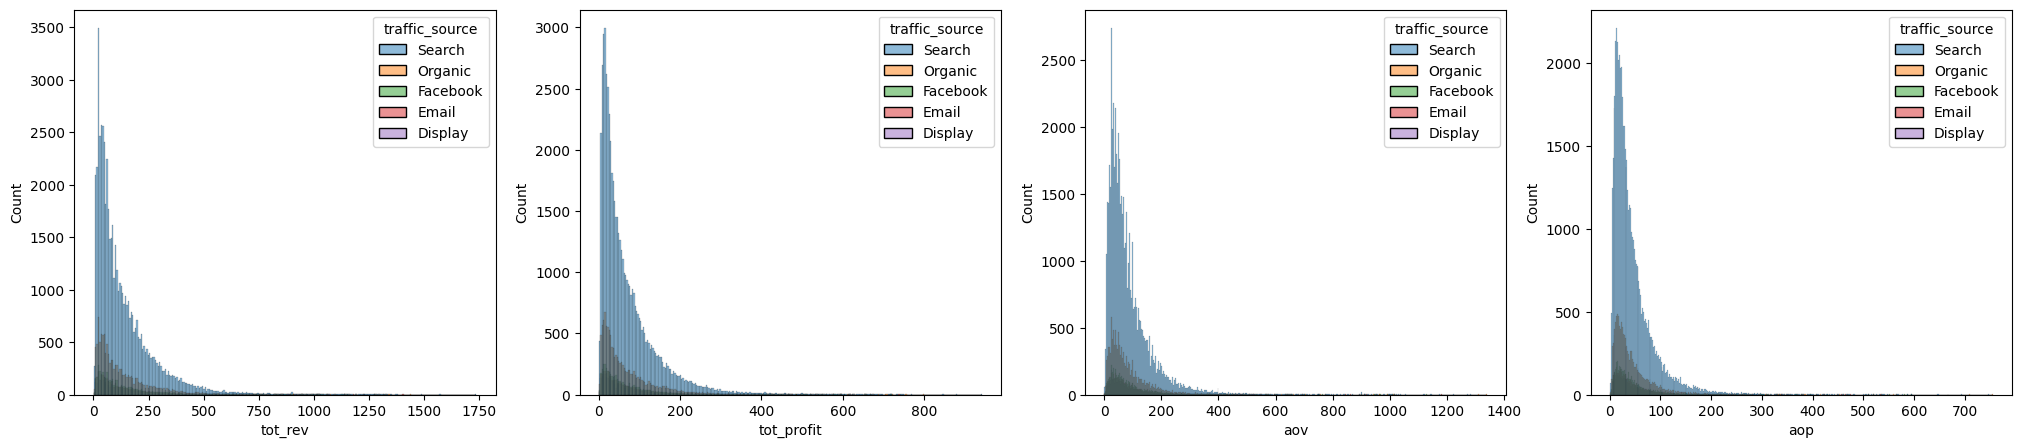

In [117]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[5]
for i in range(len(ltv)):
    sns.histplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

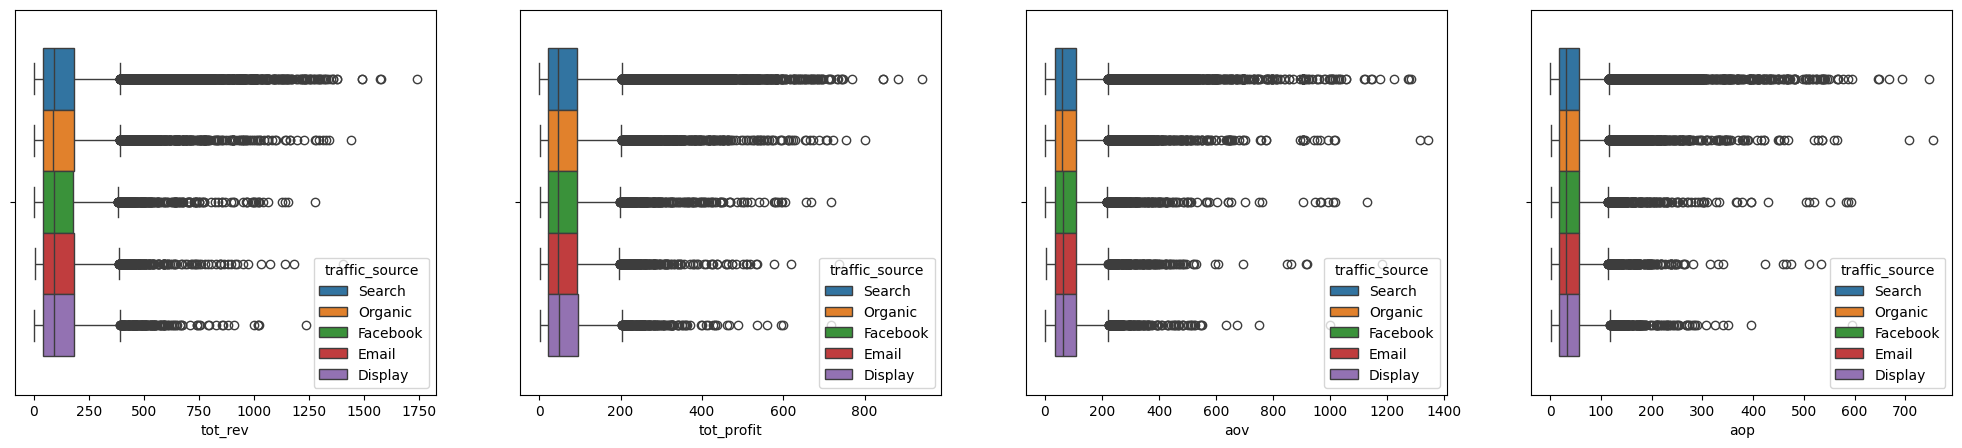

In [118]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[5]
for i in range(len(ltv)):
    sns.boxplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

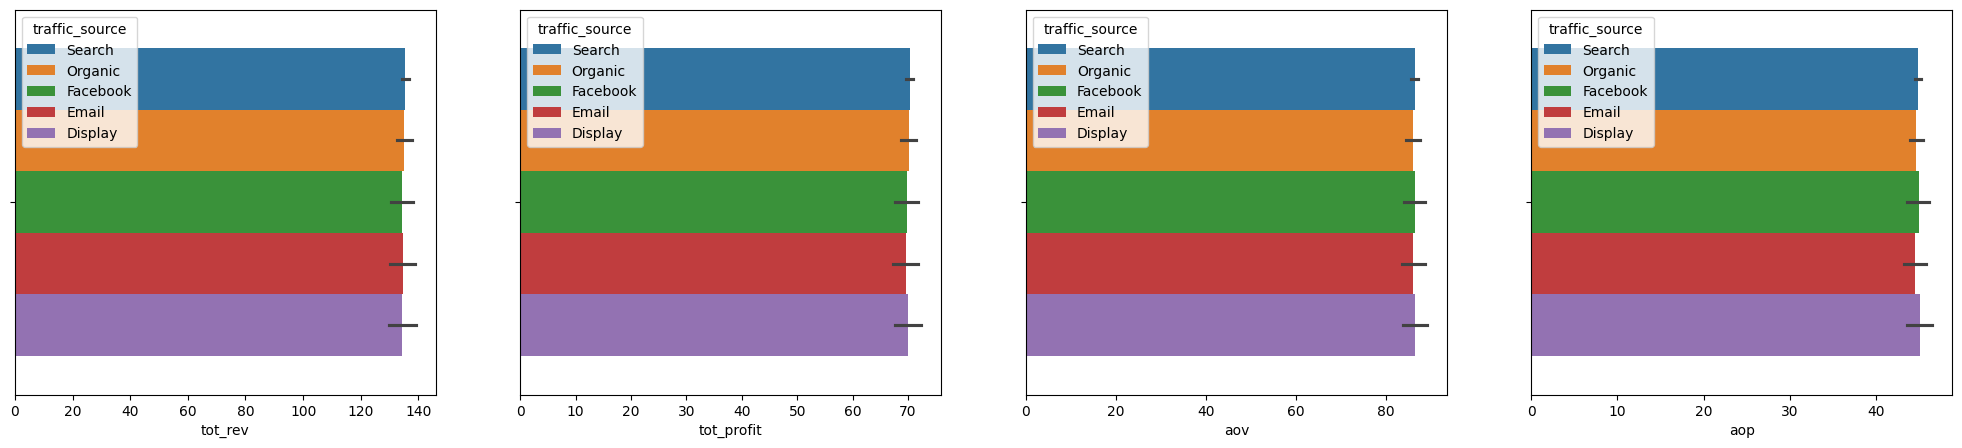

In [119]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[5]
for i in range(len(ltv)):
    sns.barplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

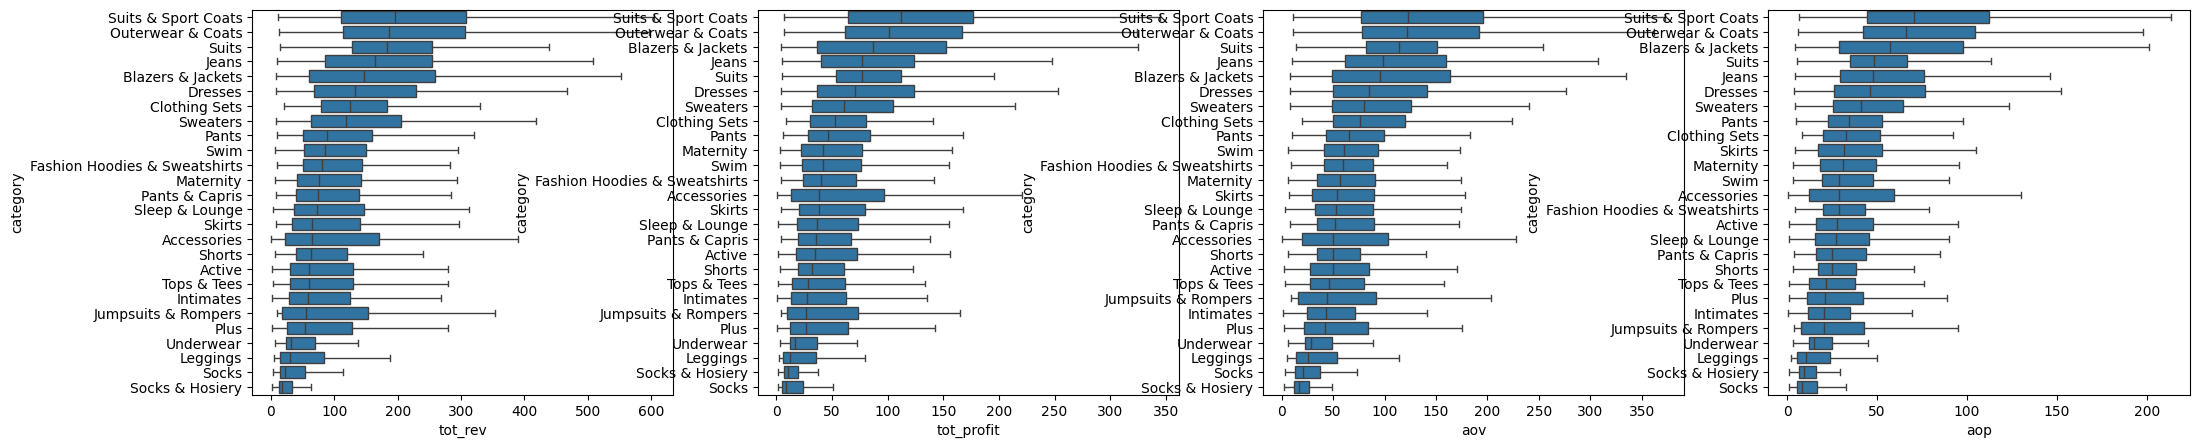

In [145]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[6]
for i in range(len(ltv)):
    v_order = user_value.groupby(v)[ltv[i]].median().sort_values(ascending=False).index
    sns.boxplot(data=user_value, x=ltv[i], y = v, ax=ax[i], order=v_order, showfliers=False)
plt.show()

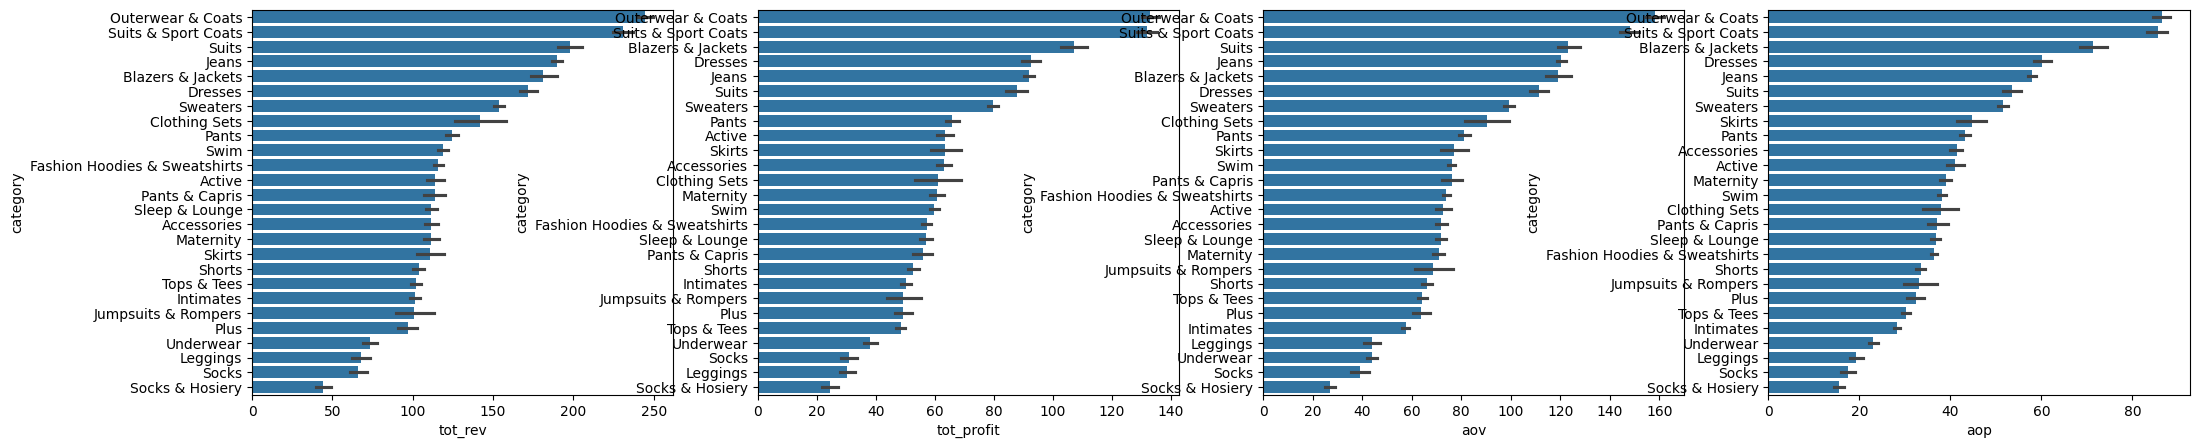

In [147]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[6]
for i in range(len(ltv)):
    v_order = user_value.groupby(v)[ltv[i]].mean().sort_values(ascending=False).index
    sns.barplot(data=user_value, x=ltv[i], y = v, ax=ax[i], order=v_order)
plt.show()

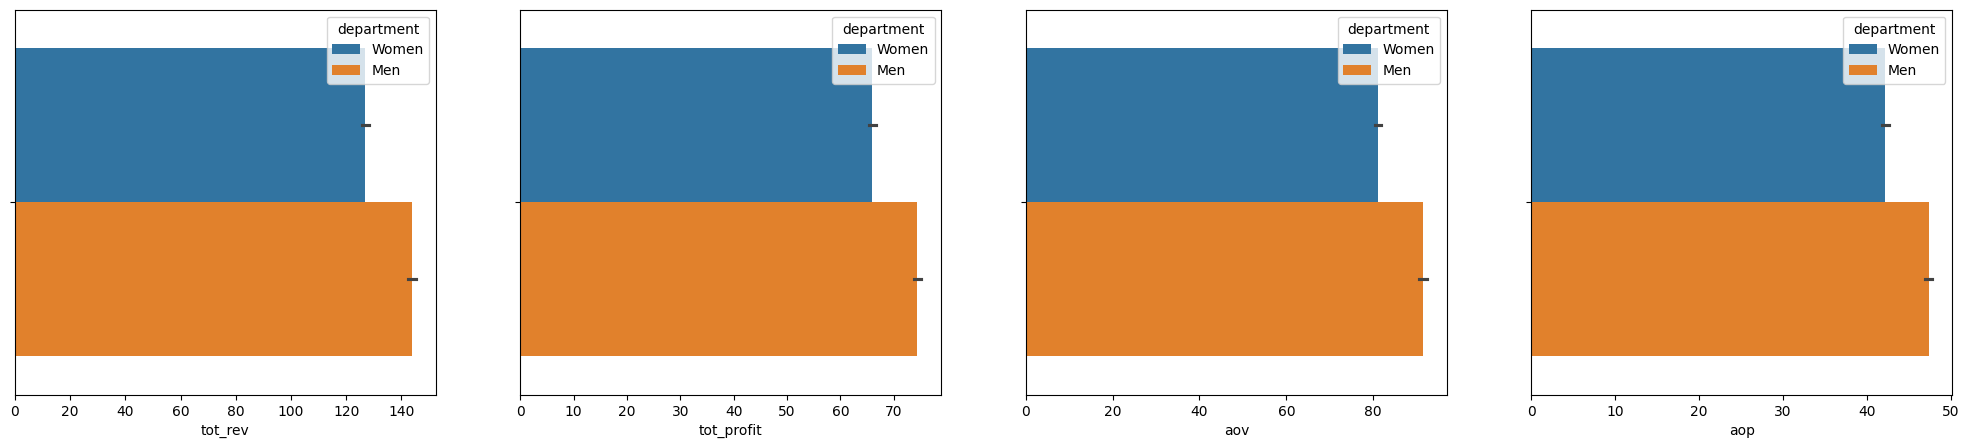

In [124]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[7]
for i in range(len(ltv)):
    sns.barplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

### Where do post-purchase drop-offs occur (e.g. returns, low engagement), and how do these vary by segment?